# Business Case:-


**Bank GoodCredit  wants to predict cred score for current credit card 
customers. The cred score will denote a customer’s credit worthiness 
and help the bank in reducing credit default risk.**

In [11]:
import sys
!{sys.executable} -m pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable


In [15]:
## importing libraries
import numpy as np                  # importing numpy for mathematical/numerical analysis
import pandas as pd                 # importing pandas for analyzing, manipulation or claeaning data
import seaborn as sns               # importing seaborn for visualize the data
import matplotlib.pyplot as plt     # importing matplotlib for visualize and ploting the statistical data
import warnings                     # importing warnings to ignore any type of warnings
warnings.filterwarnings('ignore')   # filter warnings to ignore
import mysql.connector              # to connect the sql server to fetch the dataset

In [16]:

# making a connection by using credentials
conn = mysql.connector.connect(
    host= '18.136.157.135',
    user= 'dm_team1',
    password="DM!$Team&279@20!",
    database="project_banking"
)

ConnectionTimeoutError: 2003: Can't connect to MySQL server on '18.136.157.135:3306' (Errno 10060: A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond)

In [ ]:
# List of table names present in the database
tables = ['Cust_Account','Cust_Enquiry','Cust_Demographics']

# Loop through each table in the list
for i in tables:     
    query = f'SELECT * FROM {i}'       # SQL query to fetch all records from the current table
    data = pd.read_sql(query,conn)     # Execute the SQL query and store the result in a pandas DataFrame
    data.to_csv(f'{i}.csv',index=False)   # Save the DataFrame as a CSV file with the table name
    print((f'{i} downloaded successfully'))  # Print confirmation message after successful download

# Close the database connection after all tables are downloaded
conn.close()

In [ ]:
# load a dataset

cust_account = pd.read_csv('Cust_Account.csv')   # fetch the cust_account dataset
cust_enquiry = pd.read_csv('Cust_Enquiry.csv')   # fetch the cust_enquiry dataset
cust_demographics = pd.read_csv('Cust_Demographics.csv')    # fetch the cust_demographics dataset

In [ ]:
## to show all the columns in the display
pd.set_option('display.max_columns',None) 
# cust_account    # this data contains the customer’s historical account information

In [ ]:
# This data contains Current customer applications with demographic data 
cust_demographics    

In [ ]:
cust_demographics

In [ ]:
# this data includes historical enquiry information which reflecting the customer’s credit-seeking behavior
cust_enquiry

# Domain Analysis

Credit score evaluation represents a customer’s creditworthiness and plays a vital role in helping banks reduce credit default risk. By analyzing a customer’s historical account behavior, enquiry patterns, and demographic attributes, financial institutions can make informed lending decisions and proactively identify high-risk customers.

#### Target Variable: `Bad_label`
- **0** → Customer has a **good credit history**
- **1** → Customer has a **bad credit history** (falls into the **30+ Days Past Due (DPD)** category)

**The dataset is organized into three relational tables:**

##### 1. Customer Account Data (`Cust_Account`)
This table contains the customer’s historical account information, including account details, repayment behavior, and payment history, which are crucial indicators of credit performance.

##### 2. Customer Enquiry Data (`Cust_Enquiry`)
This table includes historical enquiry information such as enquiry amount, enquiry purpose, and enquiry frequency, reflecting the customer’s credit-seeking behavior.

##### 3. Customer Demographics Data (`Cust_Demographics`)
This table consists of current customer application data along with demographic attributes.  
*Note: Demographic features have been renamed and anonymized in accordance with data privacy and confidentiality policies.*

### Data Extraction Process

- A secure database connection was established using authentication credentials.
- The tables `Cust_Account`, `Cust_Enquiry`, and `Cust_Demographics` were queried individually.
- Each table was exported as a separate CSV file to facilitate data preprocessing, exploratory data analysis, and model development.


### Project Explanation

To support credit risk analysis, data was extracted from a relational database consisting of three normalized tables: customer account details, customer enquiry history, and customer demographic information. Using SQL queries and a database connection, each table was retrieved and stored as an individual CSV file to preserve data integrity. This structured approach allows the datasets to be analyzed independently or merged using a common customer identifier, enabling effective modeling of the target variable `Bad_label` for predicting customer creditworthiness and minimizing credit default risk.


In [ ]:
# merging datasets by using common columns 'customer_no' and apply inner join
final_data = pd.merge(cust_account,cust_demographics,on = 'customer_no',how = 'inner')
final_data

In [ ]:
# saving merging dataset
final_data.to_csv('Bank_GoodCredit.csv',index=False)

In [ ]:
# call csv file which we save as a final data
data = pd.read_csv('Bank_GoodCredit.csv')
data

### Basic Checks

In [ ]:
# first five rows
data.head()

In [ ]:
# last five rows
data.tail()

In [14]:
# information about the data
data.info()

NameError: name 'data' is not defined

In [ ]:
data.columns

In [ ]:
data.dtypes

In [ ]:
# checking for data balanced
data.Bad_label.value_counts()

In [ ]:
data.describe()

In [ ]:
data.describe(include='O')

## Data Preprocessing

In [ ]:
# checking null values
data.isnull().sum()

* *Most of the columns contain missing values; therefore, an analysis was performed to identify columns with more than 40% null values.*

* *These columns were dropped because a high proportion of missing data reduces their informational value, makes reliable imputation difficult, and can negatively impact model performance by introducing noise and bias.*

In [ ]:
# Create an empty list to store column names with high null values
null=[]

# Iterate through each column in the dataset
for i in data.columns:
    # Calculate the percentage of null values in the current column
    null_percentage = (data[i].isnull().sum() / len(data)) * 100

    if null_percentage >=40:   # checking if null values is greater than or equla to 40% 
        null.append(i)    # then append the columns in the empty list

In [ ]:
print(null)

In [ ]:
# dropping that columns which are having more than 40% of the null values
data.drop(columns=['closed_dt', 'amt_past_due', 'paymenthistory2', 'creditlimit', 'cashlimit', 'rateofinterest',
                   'paymentfrequency', 'actualpaymentamount', 'feature_8', 'feature_9', 'feature_10', 'feature_13',
                   'feature_17', 'feature_18', 'feature_45', 'feature_48', 'feature_49', 'feature_51', 'feature_53',
                   'feature_57', 'feature_61', 'feature_73', 'feature_74'],axis=1,inplace = True)

In [ ]:
data

In [ ]:
## checking for duplicate values in our data

data.duplicated().sum()

In [ ]:
# as we can see that we 2438 duplicate rows so I'm going to drop the duplicated rows

data = data.drop_duplicates()

In [ ]:
# Now, we can see that we removed all duplicates columns
data.duplicated().sum()

In [ ]:
data

In [ ]:
# columns which are outside of feature scope

col = ['dt_opened_x','upload_dt','last_paymt_dt','reporting_dt','paymenthistory1','paymt_str_dt','paymt_end_dt','dt_opened_y','entry_time',
      'feature_2','feature_20','feature_21','feature_22','feature_24','feature_46','feature_47',
      'feature_54','feature_75','feature_77','feature_39','feature_79','feature_6','feature_5','feature_62','feature_70']

# iterate through selcted columns to check the values counts
for i in col:
    valuecount = data[i].value_counts()       # put value count of selected columns in a variable
    print(valuecount)                         # print the values count
    print('**************************')       # print * to separate a columns

#### *Insights*

* *From the analysis, it is observed that the selected columns contain either a **single constant value** across all records or **irrelevant/unnecessary** information.*
* *Such features do not contribute to learning meaningful patterns and may introduce **noise into the model**.*
* *Therefore, these columns are dropped to **reduce dimensionality**, improve data quality, and enhance overall modeling accuracy.*

In [ ]:
# dropping selected columns 
data.drop(col,axis = 1,inplace=True)

In [ ]:
data

In [ ]:
# to displaying the max rows
pd.set_option('display.max_rows',None)

In [ ]:
# searching for null values in each columns
data.isnull().sum()

**opened_dt**

In [ ]:
data['opened_dt'].value_counts()

In [ ]:
# replacing null values with mode
data.loc[data['opened_dt'].isnull(),'opened_dt'] = '13-Apr-12'

In [ ]:
data['opened_dt'].isnull().sum()

**high_credit_amt**

In [6]:
data['high_credit_amt'].value_counts()

NameError: name 'data' is not defined

In [ ]:
# this data didn't show the normal distribution
# so, replace null values by using median

data.loc[data['high_credit_amt'].isnull(),'high_credit_amt'] = data['high_credit_amt'].median()

In [ ]:
data['high_credit_amt'].isnull().sum()

**feature_1**

In [ ]:
data['feature_1'].value_counts()

In [ ]:
# replacing null values by using mode

data.loc[data['feature_1'].isnull(),'feature_1'] = 'Platinum Maxima'

In [ ]:
data['feature_1'].isnull().sum()

**feature_3**

In [ ]:
data['feature_3'].value_counts()

In [ ]:
sns.distplot(data.feature_3)

In [ ]:
# As this columns has no normal distribution
# i'm replacing this columns by median

data.loc[data['feature_3'].isnull(),'feature_3'] = data['feature_3'].median()

In [ ]:
data['feature_3'].isnull().sum()

**feature_4**

In [ ]:
data['feature_4'].value_counts()

In [ ]:
# replacing null values by using mode

data.loc[data['feature_4'].isnull(),'feature_4'] = 3.0

In [ ]:
data['feature_4'].isnull().sum()

**feature_7**

In [ ]:
data['feature_7'].value_counts()

In [ ]:
sns.distplot(data['feature_7'])

In [ ]:
# as we can see that this columns is not showing normal distribution
# i'm replacing null values by using median

data.loc[data['feature_7'].isnull(),'feature_7'] = data['feature_7'].median()

In [ ]:
data['feature_7'].isnull().sum()

**feature_11**

In [ ]:
data['feature_11'].value_counts()

In [ ]:
## i'm replacing null values by using mode
data.loc[data['feature_11'].isnull(),'feature_11'] = 'Y'

In [ ]:
data['feature_11'].isnull().sum()

**feature_12**

In [ ]:
data['feature_12'].value_counts()

In [ ]:
# i'm replacing null values by using mode

data.loc[data['feature_12'].isnull(),'feature_12'] = 'PM1'

In [ ]:
data['feature_12'].isnull().sum()

**feature_14**

In [59]:
data['feature_14'].value_counts()

feature_14
12.0    77405
0.0     45923
Name: count, dtype: int64

In [60]:
# i'm manually replacing null values

data.loc[data['feature_14'].isnull(),'feature_14'] = 12.0

In [61]:
data['feature_14'].isnull().sum()

np.int64(0)

**feature_15**

In [62]:
data['feature_15'].value_counts()

feature_15
SA03    68082
HA03     9394
SA01     8746
SA05     7794
W01      6548
MA03     5509
SARE     4812
SA32     4156
HA08     4059
SA40     4022
BA05     3574
HA06     3196
SA43     2806
AC01     2753
SA31     2696
BBOL     2127
CD01     1854
MA25     1715
HA07     1493
DD01     1381
MA02     1274
MA24     1070
PA01     1004
SA38      993
MA01      957
HA09      931
DM02      909
CH08      884
PBOL      791
MA20      772
SA14      715
HARI      704
MA14      704
88        662
DGM1      653
DP02      626
BBD1      624
IB06      623
AM01      613
SA35      608
AC02      583
142       582
IB04      577
CM02      565
DA06      552
PA11      525
MA16      461
SA06      458
VR03      445
RPOL      401
DP14      388
W02       384
SA37      349
PA05      334
MA29      331
CH01      324
IB02      319
SA36      296
IB05      290
159       284
MA13      283
DS08      272
100       267
112       261
SA02      250
SA07      241
10        235
1         233
114       232
PA02      221
HA10     

In [63]:
# i'm repalcing null values by using mode

data.loc[data['feature_15'].isnull(),'feature_15'] = 'SA03'

In [64]:
data['feature_15'].isnull().sum()

np.int64(0)

**feature_16**

In [65]:
data['feature_16'].value_counts()

feature_16
AS03    9256
AS19    9151
AS16    9049
AS17    8288
MA01    7157
AS34    6203
AS06    5953
AS32    5736
AS33    5416
G009    4947
AS11    4900
VA03    3729
VA01    3502
IC01    3436
AS15    3231
RM04    2927
D077    2783
G011    2697
G010    2605
RK01    2462
IN01    2140
V001    2046
VA02    1999
TMS1    1710
RK02    1679
AS18    1518
D073    1471
VRP1    1420
D066    1417
3056    1335
H006    1308
VRP2    1181
M032    1177
SRC1    1072
H013    1050
AS04    1048
VRP4    1043
A005    1009
D067     994
FS02     982
RM03     979
H004     870
HA01     868
RSN1     859
G007     838
D135     785
D120     771
M001     753
S203     735
M037     730
G014     718
MA03     709
D054     702
S202     702
S204     693
SI03     671
C005     657
V003     647
D094     640
G013     632
C009     630
SR01     614
RM02     594
AS31     580
S001     554
AG01     553
SP01     531
MGT2     531
D122     523
M014     519
SI02     499
D041     497
D036     497
D023     484
D095     467
D123     459
S

In [66]:
# i'm replacing null values by using mode

data.loc[data['feature_16'].isnull(),'feature_16'] = 'AS03'

In [67]:
data['feature_16'].isnull().sum()

np.int64(0)

**feature_19**

In [68]:
data['feature_19'].value_counts()

feature_19
1.0    176507
2.0      7260
Name: count, dtype: int64

In [69]:
# i'm replacing null values by using mode

data.loc[data['feature_19'].isnull(),'feature_19'] = 1.0

In [70]:
data['feature_19'].isnull().sum()

np.int64(0)

**feature_23**

In [71]:
data['feature_23'].value_counts()

feature_23
N    162285
Y     21482
Name: count, dtype: int64

In [72]:
# i'm replacing the values by using mode

data.loc[data['feature_23'].isnull(),'feature_23'] = 'N'

In [73]:
data['feature_23'].isnull().sum()

np.int64(0)

**feature_25**

In [74]:
data['feature_25'].value_counts()

feature_25
1.0    154407
2.0     29360
Name: count, dtype: int64

In [75]:
data.loc[data['feature_25'].isnull(),'feature_25'] = 1.0

In [76]:
data['feature_25'].isnull().sum()

np.int64(0)

**feature_26**

In [77]:
data['feature_26'].value_counts()

feature_26
0.0     108448
2.0      38944
1.0      18671
3.0      12794
4.0       3612
5.0       1047
6.0        177
7.0         45
10.0        22
8.0          5
9.0          2
Name: count, dtype: int64

In [78]:
data.loc[data['feature_26'].isnull(),'feature_26'] = 0.0

In [79]:
data['feature_26'].isnull().sum()

np.int64(0)

**feature_27**

In [80]:
data['feature_27'].value_counts()

feature_27
Graduate         108636
Post-Graduate     36573
MBA/MMS            2325
Diploma            1837
Others             1501
Doctor             1242
Professional       1070
Engineer            621
CA                  339
Architect            24
Name: count, dtype: int64

In [81]:
data.loc[data['feature_27'].isnull(),'feature_27'] = 'Graduate'

In [82]:
data['feature_27'].isnull().sum()

np.int64(0)

**feature_28**

In [83]:
data['feature_28'].value_counts()

feature_28
New Delhi                       86472
Hyderabad / Secunderabad        21281
Mumbai / Navi Mumbai / Thane    16309
Ghaziabad                       10294
Gurgaon                         10075
Faridabad                        7580
Noida / Greater Noida            5684
Bengaluru                        5185
Ahmedabad                        5042
Vadodara                         3819
Pune                             2402
Chennai                          2145
Rangareddy                       1963
Kanchipuram                      1007
Coimbatore                        941
Tiruvallur                        772
Kolhapur                          463
Medak                             428
Kolkata / Howrah                  390
Surat                             310
Gandhinagar                       251
Gautam Buddha Nagar               202
Nagpur                            171
Lucknow                            85
Bhopal                             40
Panipat                            40
C

In [84]:
data.loc[data['feature_28'].isnull(),'feature_28'] = 'New Delhi'

In [85]:
data['feature_28'].isnull().sum()

np.int64(0)

**feature_29**

In [86]:
data['feature_29'].value_counts()

feature_29
110059.0    7373
122001.0    6642
110092.0    4508
110085.0    4134
201301.0    4074
110018.0    3374
121001.0    2828
110062.0    2646
201010.0    2528
110045.0    2488
201001.0    2161
110044.0    2134
110019.0    2127
110053.0    1946
110034.0    1836
500072.0    1795
110096.0    1740
110027.0    1615
110094.0    1555
110032.0    1522
110017.0    1516
110091.0    1495
110075.0    1494
110025.0    1448
201005.0    1392
110051.0    1380
110041.0    1370
110043.0    1348
110009.0    1255
110086.0    1249
110030.0    1201
122002.0    1183
110052.0    1180
500018.0    1133
110015.0    1120
110088.0    1111
201014.0    1091
110008.0    1037
110058.0    1037
110024.0    1036
110006.0    1030
121003.0    1025
110095.0    1004
110063.0    1002
110007.0     998
110064.0     992
110037.0     991
110084.0     988
110005.0     980
110065.0     974
110046.0     954
110031.0     943
110033.0     910
110093.0     833
121002.0     826
121004.0     808
500049.0     747
110014.0     724
110

<Axes: xlabel='feature_29', ylabel='Density'>

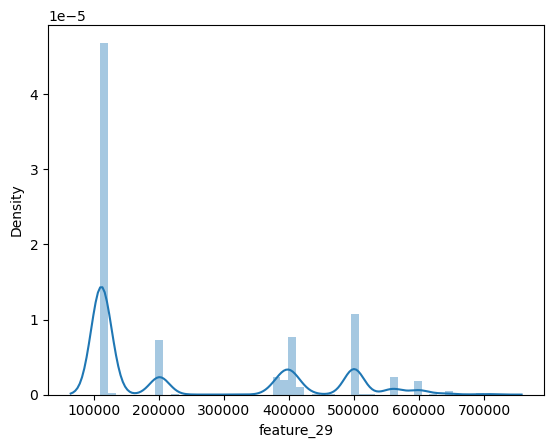

In [87]:
sns.distplot(data.feature_29)

In [88]:
# As we can see that the column is not showing normal distribution
# so I'm replacing null values with the median

data.loc[data['feature_29'].isnull(),'feature_29'] = data['feature_29'].median()

In [89]:
data['feature_29'].isnull().sum()

np.int64(0)

**feature_30**

In [90]:
data['feature_30'].value_counts()

feature_30
2010.0    13749
2000.0    13449
2012.0    12428
2013.0    11632
2011.0    10770
2005.0    10451
2014.0     9177
2009.0     7848
1995.0     6532
2008.0     6407
2007.0     6385
1990.0     5651
1985.0     5272
2003.0     3899
2006.0     3805
1980.0     3759
2015.0     3094
2004.0     2825
1984.0     2784
2001.0     2753
1986.0     2491
1987.0     2448
1983.0     2426
2002.0     2379
1988.0     2314
1982.0     2239
1989.0     1981
1999.0     1955
1981.0     1841
1979.0     1807
1975.0     1743
1964.0     1660
1978.0     1441
1976.0     1191
1992.0     1183
1998.0     1169
1977.0     1103
1993.0     1069
1991.0     1004
1974.0     1001
1997.0      997
1970.0      863
1973.0      706
1972.0      656
1969.0      630
1994.0      624
1996.0      620
1965.0      451
1971.0      375
1968.0      264
1967.0      239
1966.0      227
Name: count, dtype: int64

In [91]:
data.loc[data['feature_30'].isnull(),'feature_30'] = 2010.0

In [92]:
data['feature_30'].isnull().sum()

np.int64(0)

**feature_31**

In [93]:
data['feature_31'].value_counts()

feature_31
0.0     165620
1.0       4655
12.0      3258
6.0       1522
11.0      1473
4.0       1402
9.0       1147
3.0        930
2.0        850
5.0        780
8.0        736
7.0        729
10.0       665
Name: count, dtype: int64

In [94]:
data.loc[data['feature_31'].isnull(),'feature_31'] = 0.0

In [95]:
data['feature_31'].isnull().sum()

np.int64(0)

**feature_32**

In [96]:
data['feature_32'].value_counts()

feature_32
Self     91274
Paren    46436
Rente    44698
Compa     1044
PG/Ho      315
Name: count, dtype: int64

In [97]:
data.loc[data['feature_32'].isnull(),'feature_32'] = 'Self'

In [98]:
data['feature_32'].isnull().sum()

np.int64(0)

**feature_33**

In [99]:
data['feature_33'].value_counts()

feature_33
Y    158402
N     25365
Name: count, dtype: int64

In [100]:
data.loc[data['feature_33'].isnull(),'feature_33'] = 'Y'

In [101]:
data['feature_33'].isnull().sum()

np.int64(0)

**feature_34**

In [102]:
data['feature_34'].value_counts()

feature_34
1.0    132288
2.0     51167
3.0       312
Name: count, dtype: int64

In [103]:
data.loc[data['feature_34'].isnull(),'feature_34'] = 1.0

In [104]:
data['feature_34'].isnull().sum()

np.int64(0)

**feature_35**

In [105]:
data['feature_35'].value_counts()

feature_35
1.0           60898
40000.0       14128
50000.0       10099
30000.0        9391
35000.0        6246
45000.0        4652
100000.0       3863
60000.0        3560
25000.0        3379
80000.0        2454
42000.0        1865
70000.0        1750
32000.0        1440
28000.0        1211
150000.0       1061
38000.0        1003
55000.0         930
75000.0         872
48000.0         797
26000.0         770
41000.0         762
65000.0         757
200000.0        748
27000.0         700
20000.0         646
36000.0         643
33000.0         626
43000.0         614
90000.0         540
39000.0         510
34000.0         472
52000.0         472
29000.0         466
44000.0         434
31000.0         433
37000.0         374
47000.0         333
58000.0         322
46000.0         320
300000.0        302
56000.0         233
54000.0         227
85000.0         222
250000.0        221
51000.0         198
500000.0        182
22000.0         180
120000.0        179
49000.0         173
62000.0  

<Axes: xlabel='feature_35', ylabel='Density'>

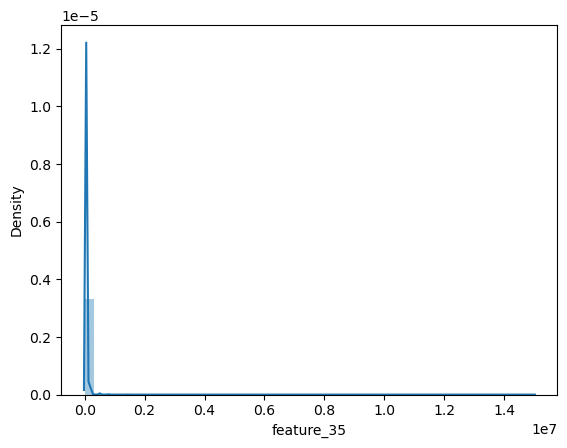

In [106]:
sns.distplot(data.feature_35)

In [107]:
# as we cann see that the column not showing normal distribution
# i'm removing null values by using median

data.loc[data['feature_35'].isnull(),'feature_35'] = data['feature_35'].median()

In [108]:
data['feature_35'].isnull().sum()

np.int64(0)

**feature_36**

In [109]:
data['feature_36'].value_counts()

feature_36
Private Ltd. Co.           61140
Public Ltd Co.             42735
MNC                        11136
Proprietorship             11018
Government Organisation     5846
Partnership Co.              178
PSU                          176
Partnership                   54
Others                         5
Name: count, dtype: int64

In [110]:
data.loc[data['feature_36'].isnull(),'feature_36'] = 'Private Ltd. Co.'

In [111]:
data['feature_36'].isnull().sum()

np.int64(0)

**feature_37**

In [112]:
data['feature_37'].value_counts()

feature_37
Banking/Financial Services    96629
Others                        23390
Information Technology         6013
Industrial                     2147
KPO/LPO/ITES                   1513
Health Care                    1209
Manufacturing                   522
Transportation/Logistics        408
Real Estate                     258
Tourism                         185
Agriculture                      14
Name: count, dtype: int64

In [113]:
data.loc[data['feature_37'].isnull(),'feature_37'] = 'Banking/Financial Services'

In [114]:
data['feature_37'].isnull().sum()

np.int64(0)

**feature_38**

In [115]:
data['feature_38'].value_counts()

feature_38
MANAGER                                     13482
ASST MANAGER                                 5913
EXECUTIVE                                    3784
SR EXECUTIVE                                 3445
SR MANAGER                                   2578
SALES MANAGER                                1872
ACCOUNTANT                                   1626
TEAM LEADER                                  1618
DEPUTY MANAGER                               1572
OFFICER                                      1398
ASSISTANT MANAGER                            1113
ENGINEER                                     1092
DIRECTOR                                     1023
STORE MANAGER                                 946
PROJECT MANAGER                               814
SUPERVISOR                                    743
GENERAL MANAGER                               729
SR ENGINEER                                   663
ASSOCIATE                                     650
SR ASSOCIATE                           

In [116]:
data.loc[data['feature_38'].isnull(),'feature_38'] = 'MANAGER'

In [117]:
data['feature_38'].isnull().sum()

np.int64(0)

**feature_40**

In [118]:
data['feature_40'].value_counts()

feature_40
0.0     59560
1.0     37067
6.0     12504
2.0     11117
3.0     10397
4.0     10281
5.0      7219
8.0      7115
7.0      7078
9.0      6709
11.0     5053
12.0     4860
10.0     4807
Name: count, dtype: int64

In [119]:
data.loc[data['feature_40'].isnull(),'feature_40'] = 0.0

In [120]:
data['feature_40'].isnull().sum()

np.int64(0)

**feature_41**

In [121]:
data['feature_41'].value_counts()

feature_41
0.0     53110
11.0    50038
10.0    14562
8.0     12569
5.0     10638
7.0     10550
6.0      9071
9.0      8107
4.0      5958
3.0      4767
2.0      2828
1.0      1569
Name: count, dtype: int64

In [122]:
data.loc[data['feature_41'].isnull(),'feature_41'] = 0.0

In [123]:
data['feature_41'].isnull().sum()

np.int64(0)

**feature_42**

In [124]:
data['feature_42'].value_counts()

feature_42
0.0     179833
5.0       1758
6.0       1101
1.0        221
3.0        208
8.0        154
2.0        117
4.0        116
7.0        107
9.0         79
10.0        51
11.0        22
Name: count, dtype: int64

In [125]:
data.loc[data['feature_42'].isnull(),'feature_42'] = 1.0

In [126]:
data['feature_42'].isnull().sum()

np.int64(0)

**feature_43**

In [127]:
data['feature_43'].value_counts()

feature_43
New Delhi                 69355
Gurgaon                   24416
Hyderabad                 21535
Noida                     17899
Mumbai                    12663
Bangalore                  5139
Ahmedabad                  5130
Faridabad                  4499
Vadodara                   3763
Ghaziabad                  3618
Thane                      2698
Chennai                    2568
Pune                       2408
Rangareddy                 1728
Kanchipuram                 949
Coimbatore                  875
Navi mumbai                 767
Kolhapur                    514
Greater Noida               429
Kolkata                     397
Tiruvallur                  375
Surat                       336
Medak                       263
RAIGARHMH                   215
Nagpur                      171
Gandhinagar                 166
Secunderabad                151
Lucknow                      85
Gautam Buddha Nagar          76
Guntur                       41
Bhopal                       

In [128]:
data.loc[data['feature_43'].isnull(),'feature_43'] = 'New Delhi'

In [129]:
data['feature_43'].isnull().sum()

np.int64(0)

**feature_44**

In [130]:
data['feature_44'].value_counts()

feature_44
201301.0    15128
122001.0    13439
122002.0     5556
110001.0     4152
110020.0     3430
110092.0     2888
500081.0     2675
110019.0     2321
110085.0     2216
110005.0     2184
110015.0     2170
110059.0     2161
121001.0     1968
110034.0     1935
110018.0     1840
110017.0     1689
110044.0     1627
122016.0     1543
500016.0     1525
500034.0     1493
110058.0     1470
110027.0     1460
110006.0     1450
110024.0     1407
110037.0     1393
110002.0     1379
201010.0     1302
500082.0     1197
110008.0     1149
122015.0     1101
110025.0     1093
110016.0     1070
110003.0     1067
400013.0     1067
500032.0     1008
201305.0      982
110053.0      957
110041.0      936
110055.0      929
110065.0      903
110052.0      897
500072.0      853
500003.0      848
110028.0      839
110075.0      805
110064.0      803
110007.0      782
110048.0      780
201306.0      760
201001.0      758
122050.0      747
110030.0      744
110033.0      736
390007.0      729
121003.0      726

<Axes: xlabel='feature_44', ylabel='Density'>

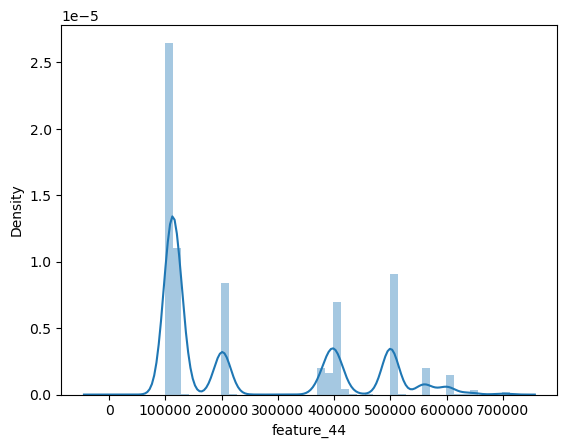

In [131]:
sns.distplot(data.feature_44)

In [132]:
## as we can see that the columns is not showing normal distribution 
## so i'm replacing the null values using median

data.loc[data['feature_44'].isnull(),'feature_44'] = data['feature_44'].median()

In [133]:
data['feature_44'].isnull().sum()

np.int64(0)

**feature_50**

In [134]:
data['feature_50'].value_counts()

feature_50
Y    102422
N     81345
Name: count, dtype: int64

In [135]:
data.loc[data['feature_50'].isnull(),'feature_50'] = 'Y'

In [136]:
data['feature_50'].isnull().sum()

np.int64(0)

**feature_52**

In [137]:
data['feature_52'].value_counts()

feature_52
0.0          84166
100000.0      4928
50000.0       4915
75000.0       3556
60000.0       2656
150000.0      2330
65000.0       1957
300000.0      1838
600000.0      1765
200000.0      1570
52000.0       1516
80000.0       1335
90000.0       1310
70000.0       1273
125000.0      1211
62000.0       1138
130000.0      1136
105000.0      1030
85000.0        976
67000.0        928
120000.0       923
57000.0        908
55000.0        900
110000.0       868
97000.0        867
175000.0       814
58000.0        782
78000.0        770
113000.0       761
250000.0       752
91000.0        717
87000.0        710
106000.0       692
135000.0       665
112000.0       633
108000.0       631
56000.0        601
101000.0       585
72000.0        570
118000.0       563
104000.0       558
84000.0        556
107000.0       555
195000.0       554
68000.0        545
63000.0        521
54000.0        517
102000.0       511
227000.0       500
140000.0       500
115000.0       486
79000.0        453
9

<Axes: xlabel='feature_52', ylabel='Density'>

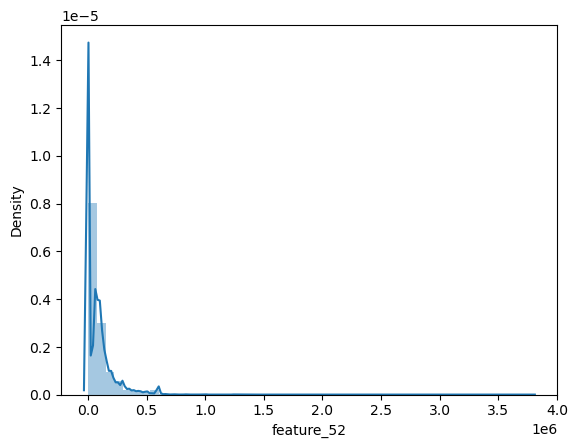

In [138]:
sns.distplot(data.feature_52)

In [139]:
## as we can see that the columns is not showing normal distribution
## so i'm removing by using median

data.loc[data['feature_52'].isnull(),'feature_52'] = data['feature_52'].median()

In [140]:
data['feature_52'].isnull().sum()

np.int64(0)

**feature_55**

In [141]:
data['feature_55'].value_counts()

feature_55
1.0    176551
3.0      5487
2.0      1603
4.0       126
Name: count, dtype: int64

In [142]:
data.loc[data['feature_55'].isnull(),'feature_55'] = 1.0

In [143]:
data['feature_55'].isnull().sum()

np.int64(0)

**feature_56**

In [144]:
data['feature_56'].value_counts()

feature_56
10.0    86472
2.0     23748
21.0    19393
13.0    17707
33.0    16273
12.0     9494
17.0     5195
31.0     4910
35.0      482
20.0       53
29.0       39
8.0         1
Name: count, dtype: int64

In [145]:
data.loc[data['feature_56'].isnull(),'feature_56'] = 10.0

In [146]:
data['feature_56'].isnull().sum()

np.int64(0)

**feature_58**

In [147]:
data['feature_58'].value_counts()

feature_58
N    179860
Y      3907
Name: count, dtype: int64

In [148]:
data.loc[data['feature_58'].isnull(),'feature_58'] = 'N'

In [149]:
data['feature_58'].isnull().sum()

np.int64(0)

**feature_59**

In [150]:
data['feature_59'].value_counts()

feature_59
Y    175419
N      8348
Name: count, dtype: int64

In [151]:
data.loc[data['feature_59'].isnull(),'feature_59'] = 'Y'

In [152]:
data['feature_59'].isnull().sum()

np.int64(0)

**feature_60**

In [153]:
data['feature_60'].value_counts()

feature_60
N    181181
Y      2586
Name: count, dtype: int64

In [154]:
data.loc[data['feature_60'].isnull(),'feature_60'] = 'N'

In [155]:
data['feature_60'].isnull().sum()

np.int64(0)

**feature_63**

In [156]:
data['feature_63'].value_counts()

feature_63
2010-0     12657
2000-0     11905
2012-0     11256
2013-0     10409
2011-0      9875
2005-0      9320
2014-0      8349
2009-0      7121
1995-0      5859
2007-0      5742
2008-0      5672
1990-0      5077
1985-0      4760
2006-0      3541
2003-0      3538
1980-0      3381
2015-0      2681
2004-0      2533
1984-0      2497
2001-0      2445
1983-0      2275
1986-0      2234
1987-0      2116
2002-0      2081
1982-0      2014
1988-0      1993
1989-0      1787
1999-0      1770
1964-0      1660
1979-0      1645
1981-0      1624
1975-0      1487
1978-0      1363
1976-0      1125
1998-0      1016
1992-0      1014
1977-0       968
1974-0       930
1993-0       929
1997-0       911
1991-0       881
1970-0       761
1973-0       661
1972-0       615
1996-0       584
1994-0       560
1969-0       556
2000-1       488
1965-0       420
2013-1       365
2005-12      356
1971-0       353
2010-1       346
2005-1       337
2012-1       310
2011-1       275
2000-12      257
1968-0       237
196

In [157]:
data.loc[data['feature_63'].isnull(),'feature_63'] = '2010-0'

In [158]:
data['feature_63'].isnull().sum()

np.int64(0)

**feature_64**

In [159]:
data['feature_64'].value_counts()

feature_64
10.0    74491
2.0     23995
33.0    20594
21.0    19153
13.0    15241
12.0     9556
17.0     5263
31.0     4974
5.0      3670
26.0     1054
35.0     1009
29.0      965
16.0      821
34.0      814
20.0      736
28.0      378
14.0      323
18.0      256
15.0      134
4.0       121
7.0        92
6.0        57
22.0       34
25.0       19
23.0       10
11.0        6
8.0         1
Name: count, dtype: int64

In [160]:
data.loc[data['feature_64'].isnull(),'feature_64'] = 10.0

In [161]:
data['feature_64'].isnull().sum()

np.int64(0)

**feature_65**

In [162]:
data['feature_65'].value_counts()

feature_65
157.0      74491
14.0       20480
15.0       10986
41.0        8983
39.0        7147
3.0         6641
12.0        5234
8.0         5031
315.0       4105
186.0       3816
71.0        3210
16.0        2192
13.0        2141
667.0       1937
494.0        988
34.0         892
835.0        804
56.0         650
7.0          559
58.0         491
75.0         488
156.0        484
144.0        481
736.0        418
127.0        410
348.0        407
1586.0       393
721.0        377
150.0        355
20.0         345
105.0        317
91.0         310
102.0        281
187.0        273
283.0        256
282.0        256
203.0        255
125.0        243
214.0        217
86.0         207
49.0         203
641.0        202
459.0        198
627.0        193
228.0        187
83.0         186
151.0        184
121.0        183
798.0        179
67.0         176
112.0        164
36.0         158
118.0        153
126.0        149
90.0         148
128.0        147
55.0         146
614.0        146
767

<Axes: xlabel='feature_65', ylabel='Density'>

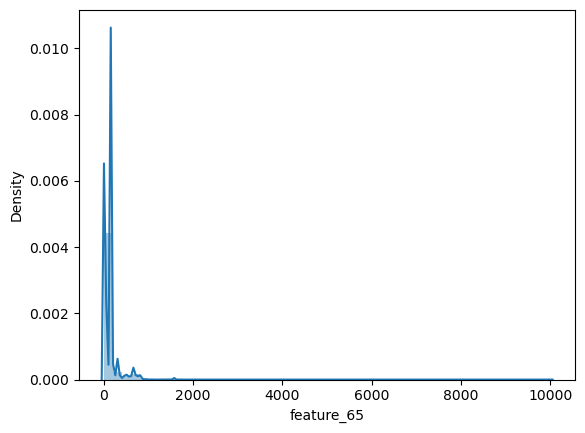

In [163]:
sns.distplot(data.feature_65)

In [164]:
## as we can see that the column is not showing normal distribution
## so i'm replacing the null value by using median

data.loc[data['feature_65'].isnull(),'feature_65'] = data['feature_65'].median()

In [165]:
data['feature_65'].isnull().sum()

np.int64(0)

**feature_66**

In [166]:
data['feature_66'].value_counts()

feature_66
110059.0    6521
122001.0    4369
110085.0    3900
110092.0    3261
110018.0    3079
201301.0    2621
121001.0    2593
110062.0    2234
110045.0    2134
201010.0    2047
110053.0    1920
201001.0    1841
110044.0    1794
110034.0    1726
500072.0    1665
110019.0    1659
110027.0    1536
110094.0    1489
110032.0    1413
201005.0    1303
110041.0    1301
110051.0    1296
110043.0    1293
110096.0    1255
110086.0    1206
110009.0    1178
110091.0    1141
110017.0    1110
110025.0    1093
110015.0    1089
500018.0    1089
110052.0    1042
110088.0    1032
110006.0    1024
110007.0     998
121003.0     986
110075.0     972
110005.0     966
110084.0     959
110024.0     954
110008.0     945
110063.0     924
110095.0     924
201014.0     914
110064.0     901
110031.0     893
110058.0     888
110033.0     858
110030.0     805
110093.0     757
110065.0     752
121004.0     752
121002.0     750
500049.0     717
110046.0     703
122002.0     691
500055.0     654
110089.0     652
110

<Axes: xlabel='feature_66', ylabel='Density'>

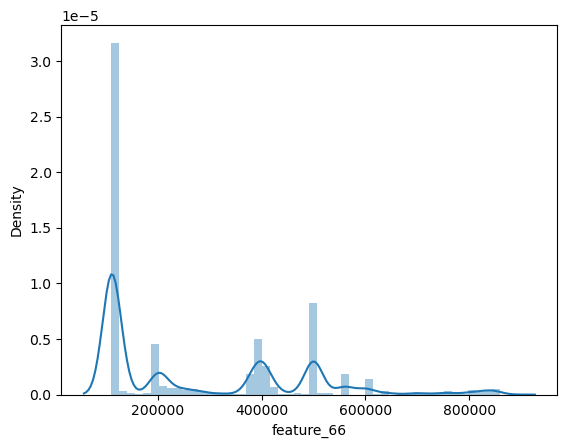

In [167]:
sns.distplot(data.feature_66)

In [168]:
# as we can see that the column is not showing normal distribution
# so i'm replacing the null values using median...

data.loc[data['feature_66'].isnull(),'feature_66'] = data['feature_66'].median()

In [169]:
data['feature_66'].isnull().sum()

np.int64(0)

**feature_67**

In [170]:
data['feature_67'].value_counts()

feature_67
0.0    158402
1.0     25365
Name: count, dtype: int64

In [171]:
data.loc[data['feature_67'].isnull(),'feature_67'] = 1.0

In [172]:
data['feature_67'].isnull().sum()

np.int64(0)

**feature_68**

In [173]:
data['feature_68'].value_counts()

feature_68
1.0    132288
2.0     51167
3.0       312
Name: count, dtype: int64

In [174]:
data.loc[data['feature_68'].isnull(),'feature_68'] = 1.0

In [175]:
data['feature_68'].isnull().sum()

np.int64(0)

**feature_69**

In [176]:
data['feature_69'].value_counts()

feature_69
1.0           60898
40000.0       14128
50000.0       10099
30000.0        9391
35000.0        6246
45000.0        4652
100000.0       3863
60000.0        3560
25000.0        3379
80000.0        2454
42000.0        1865
70000.0        1750
32000.0        1440
28000.0        1211
150000.0       1061
38000.0        1003
55000.0         930
75000.0         872
48000.0         797
26000.0         770
41000.0         762
65000.0         757
200000.0        748
27000.0         700
20000.0         646
36000.0         643
33000.0         626
43000.0         614
90000.0         540
39000.0         510
34000.0         472
52000.0         472
29000.0         466
44000.0         434
31000.0         433
37000.0         374
47000.0         333
58000.0         322
46000.0         320
300000.0        302
56000.0         233
54000.0         227
85000.0         222
250000.0        221
51000.0         198
500000.0        182
22000.0         180
120000.0        179
49000.0         173
62000.0  

<Axes: xlabel='feature_69', ylabel='Density'>

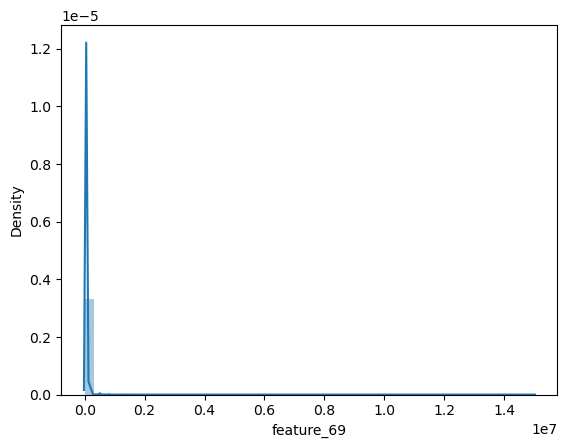

In [177]:
sns.distplot(data.feature_69)

In [178]:
# as we can see that columns not showing normal distribution
# so i'm replcing null values using median

data.loc[data['feature_69'].isnull(),'feature_69'] = data['feature_69'].median()

In [179]:
data['feature_69'].isnull().sum()

np.int64(0)

**feature_71**

In [180]:
data['feature_71'].value_counts()

feature_71
10.0    69355
13.0    28994
2.0     23756
33.0    22116
21.0    19481
12.0     9482
17.0     5176
31.0     4841
35.0      473
20.0       53
29.0       38
9.0         1
8.0         1
Name: count, dtype: int64

In [181]:
data.loc[data['feature_71'].isnull(),'feature_71'] = 10.0

In [182]:
data['feature_71'].isnull().sum()

np.int64(0)

**feature_72**

In [183]:
data['feature_72'].value_counts()

feature_72
R    128413
O     55354
Name: count, dtype: int64

In [184]:
data.loc[data['feature_72'].isnull(),'feature_72'] = 'R'

In [185]:
data['feature_72'].isnull().sum()

np.int64(0)

**feature_76**

In [186]:
data['feature_76'].value_counts()

feature_76
0.0    183070
1.0       521
2.0       132
4.0        27
3.0        17
Name: count, dtype: int64

In [187]:
data.loc[data['feature_76'].isnull(),'feature_76'] = 0.0

In [188]:
data['feature_76'].isnull().sum()

np.int64(0)

**feature_78**

In [189]:
data['feature_78'].value_counts()

feature_78
1.0    177106
2.0      5816
3.0       845
Name: count, dtype: int64

In [190]:
data.loc[data['feature_78'].isnull(),'feature_78'] = 1.0

In [191]:
# checking is there any other null values which we missed to handle
data.isnull().sum()

customer_no        0
acct_type          0
owner_indic        0
opened_dt          0
high_credit_amt    0
cur_balance_amt    0
feature_1          0
feature_3          0
feature_4          0
feature_7          0
feature_11         0
feature_12         0
feature_14         0
feature_15         0
feature_16         0
feature_19         0
feature_23         0
feature_25         0
feature_26         0
feature_27         0
feature_28         0
feature_29         0
feature_30         0
feature_31         0
feature_32         0
feature_33         0
feature_34         0
feature_35         0
feature_36         0
feature_37         0
feature_38         0
feature_40         0
feature_41         0
feature_42         0
feature_43         0
feature_44         0
feature_50         0
feature_52         0
feature_55         0
feature_56         0
feature_58         0
feature_59         0
feature_60         0
feature_63         0
feature_64         0
feature_65         0
feature_66         0
feature_67   

In [192]:
data.head()

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_23,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_43,feature_44,feature_50,feature_52,feature_55,feature_56,feature_58,feature_59,feature_60,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
0,12265,6,1,09-Jun-13,20900.0,0,Platinum Maxima,683.0,3.0,56000.0,Y,PM1,12.0,SA05,MA01,1.0,N,1.0,0.0,MBA/MMS,New Delhi,110059.0,2006.0,0.0,Paren,Y,1.0,35000.0,Private Ltd. Co.,Others,SR EXE,1.0,4.0,0.0,Gurgaon,122001.0,N,0.0,1.0,10.0,N,Y,N,2006-0,10.0,157.0,110059.0,0.0,1.0,35000.0,13.0,R,0.0,1.0,1
1,12265,10,1,25-May-12,16201.0,10390,Platinum Maxima,683.0,3.0,56000.0,Y,PM1,12.0,SA05,MA01,1.0,N,1.0,0.0,MBA/MMS,New Delhi,110059.0,2006.0,0.0,Paren,Y,1.0,35000.0,Private Ltd. Co.,Others,SR EXE,1.0,4.0,0.0,Gurgaon,122001.0,N,0.0,1.0,10.0,N,Y,N,2006-0,10.0,157.0,110059.0,0.0,1.0,35000.0,13.0,R,0.0,1.0,1
2,12265,10,1,22-Mar-12,41028.0,34420,Platinum Maxima,683.0,3.0,56000.0,Y,PM1,12.0,SA05,MA01,1.0,N,1.0,0.0,MBA/MMS,New Delhi,110059.0,2006.0,0.0,Paren,Y,1.0,35000.0,Private Ltd. Co.,Others,SR EXE,1.0,4.0,0.0,Gurgaon,122001.0,N,0.0,1.0,10.0,N,Y,N,2006-0,10.0,157.0,110059.0,0.0,1.0,35000.0,13.0,R,0.0,1.0,1
3,15606,10,1,13-Jan-06,93473.0,0,Platinum Deligh,687.0,3.0,125000.0,Y,PD1,12.0,SA35,S001,1.0,N,1.0,2.0,Post-Graduate,Faridabad,121003.0,2009.0,0.0,Self,Y,1.0,100000.0,Private Ltd. Co.,Banking/Financial Services,GENRAL MANAGER OPERATIONS,1.0,2.0,0.0,Faridabad,121003.0,N,0.0,1.0,13.0,N,Y,N,2009-0,13.0,39.0,121003.0,0.0,1.0,100000.0,13.0,R,0.0,1.0,1
4,15606,6,1,18-Jan-15,20250.0,13500,Platinum Deligh,687.0,3.0,125000.0,Y,PD1,12.0,SA35,S001,1.0,N,1.0,2.0,Post-Graduate,Faridabad,121003.0,2009.0,0.0,Self,Y,1.0,100000.0,Private Ltd. Co.,Banking/Financial Services,GENRAL MANAGER OPERATIONS,1.0,2.0,0.0,Faridabad,121003.0,N,0.0,1.0,13.0,N,Y,N,2009-0,13.0,39.0,121003.0,0.0,1.0,100000.0,13.0,R,0.0,1.0,1


In [193]:
# Converting date to datetime and extracting only the year
data['opened_dt'] = pd.to_datetime(data['opened_dt']).dt.year
data.head()

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_23,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_43,feature_44,feature_50,feature_52,feature_55,feature_56,feature_58,feature_59,feature_60,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
0,12265,6,1,2013,20900.0,0,Platinum Maxima,683.0,3.0,56000.0,Y,PM1,12.0,SA05,MA01,1.0,N,1.0,0.0,MBA/MMS,New Delhi,110059.0,2006.0,0.0,Paren,Y,1.0,35000.0,Private Ltd. Co.,Others,SR EXE,1.0,4.0,0.0,Gurgaon,122001.0,N,0.0,1.0,10.0,N,Y,N,2006-0,10.0,157.0,110059.0,0.0,1.0,35000.0,13.0,R,0.0,1.0,1
1,12265,10,1,2012,16201.0,10390,Platinum Maxima,683.0,3.0,56000.0,Y,PM1,12.0,SA05,MA01,1.0,N,1.0,0.0,MBA/MMS,New Delhi,110059.0,2006.0,0.0,Paren,Y,1.0,35000.0,Private Ltd. Co.,Others,SR EXE,1.0,4.0,0.0,Gurgaon,122001.0,N,0.0,1.0,10.0,N,Y,N,2006-0,10.0,157.0,110059.0,0.0,1.0,35000.0,13.0,R,0.0,1.0,1
2,12265,10,1,2012,41028.0,34420,Platinum Maxima,683.0,3.0,56000.0,Y,PM1,12.0,SA05,MA01,1.0,N,1.0,0.0,MBA/MMS,New Delhi,110059.0,2006.0,0.0,Paren,Y,1.0,35000.0,Private Ltd. Co.,Others,SR EXE,1.0,4.0,0.0,Gurgaon,122001.0,N,0.0,1.0,10.0,N,Y,N,2006-0,10.0,157.0,110059.0,0.0,1.0,35000.0,13.0,R,0.0,1.0,1
3,15606,10,1,2006,93473.0,0,Platinum Deligh,687.0,3.0,125000.0,Y,PD1,12.0,SA35,S001,1.0,N,1.0,2.0,Post-Graduate,Faridabad,121003.0,2009.0,0.0,Self,Y,1.0,100000.0,Private Ltd. Co.,Banking/Financial Services,GENRAL MANAGER OPERATIONS,1.0,2.0,0.0,Faridabad,121003.0,N,0.0,1.0,13.0,N,Y,N,2009-0,13.0,39.0,121003.0,0.0,1.0,100000.0,13.0,R,0.0,1.0,1
4,15606,6,1,2015,20250.0,13500,Platinum Deligh,687.0,3.0,125000.0,Y,PD1,12.0,SA35,S001,1.0,N,1.0,2.0,Post-Graduate,Faridabad,121003.0,2009.0,0.0,Self,Y,1.0,100000.0,Private Ltd. Co.,Banking/Financial Services,GENRAL MANAGER OPERATIONS,1.0,2.0,0.0,Faridabad,121003.0,N,0.0,1.0,13.0,N,Y,N,2009-0,13.0,39.0,121003.0,0.0,1.0,100000.0,13.0,R,0.0,1.0,1


In [194]:
# extracting the year from feature_63

data['feature_63'] = data['feature_63'].astype(str).str.split('-').str[0].astype(int)
data.head(1)

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_23,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_43,feature_44,feature_50,feature_52,feature_55,feature_56,feature_58,feature_59,feature_60,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
0,12265,6,1,2013,20900.0,0,Platinum Maxima,683.0,3.0,56000.0,Y,PM1,12.0,SA05,MA01,1.0,N,1.0,0.0,MBA/MMS,New Delhi,110059.0,2006.0,0.0,Paren,Y,1.0,35000.0,Private Ltd. Co.,Others,SR EXE,1.0,4.0,0.0,Gurgaon,122001.0,N,0.0,1.0,10.0,N,Y,N,2006,10.0,157.0,110059.0,0.0,1.0,35000.0,13.0,R,0.0,1.0,1


In [195]:
## changing datatypes of required columns

data['feature_3'] = data['feature_3'].astype(int)
data['feature_4'] = data['feature_4'].astype(int)
data['feature_14'] = data['feature_14'].astype(int)
data['feature_19'] = data['feature_19'].astype(int)
data['feature_25'] = data['feature_25'].astype(int)
data['feature_26'] = data['feature_26'].astype(int)
data['feature_30'] = data['feature_30'].astype(int)
data['feature_31'] = data['feature_31'].astype(int)
data['feature_34'] = data['feature_34'].astype(int)
data['feature_40'] = data['feature_40'].astype(int)
data['feature_41'] = data['feature_41'].astype(int)
data['feature_42'] = data['feature_42'].astype(int)
data['feature_52'] = data['feature_52'].astype(int)
data['feature_55'] = data['feature_55'].astype(int)
data['feature_56'] = data['feature_56'].astype(int)
data['feature_64'] = data['feature_64'].astype(int)
data['feature_65'] = data['feature_65'].astype(int)
data['feature_67'] = data['feature_67'].astype(int)
data['feature_68'] = data['feature_68'].astype(int)
data['feature_71'] = data['feature_71'].astype(int)
data['feature_76'] = data['feature_76'].astype(int)
data['feature_78'] = data['feature_78'].astype(int)

In [196]:
data.sample(10)

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_23,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_43,feature_44,feature_50,feature_52,feature_55,feature_56,feature_58,feature_59,feature_60,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
42653,15826,0,1,2014,120000.0,106275,Platinum Deligh,731,3,117000.0,Y,PD1,12,SA01,G010,1,N,2,0,Graduate,New Delhi,110037.0,2014,0,Rente,N,1,30000.0,Private Ltd. Co.,Banking/Financial Services,EXECUTIVE,4,3,0,New Delhi,110037.0,Y,55000,1,10,N,Y,N,2014,33,151,244001.0,1,1,30000.0,10,R,0,1,0
79064,1815,5,1,2011,200000.0,0,Titanium Deligh,744,3,133000.0,Y,TD1,12,SA32,RK02,1,N,1,1,Graduate,New Delhi,110027.0,1995,0,Self,Y,1,50000.0,MNC,Banking/Financial Services,SR TEAM LEADS,1,9,0,Gurgaon,122001.0,Y,70000,1,10,N,Y,N,1995,10,157,110027.0,0,1,50000.0,13,O,0,1,0
123654,17263,10,1,2007,33262.0,0,Platinum Deligh,810,1,381000.0,Y,PD1,12,SA03,AS32,1,N,1,2,Graduate,New Delhi,110096.0,2009,0,Rente,Y,1,1.0,Public Ltd Co.,Banking/Financial Services,PROJECT MANAGER,4,1,0,New Delhi,110070.0,Y,293000,1,10,N,Y,N,2009,10,157,110096.0,0,1,1.0,10,R,0,1,0
73879,15820,10,1,2015,16089.0,7963,Platinum Deligh,728,3,145000.0,Y,PD1,12,SA01,G011,1,N,1,2,Post-Graduate,New Delhi,110057.0,2010,0,Compa,N,1,40000.0,Government Organisation,Banking/Financial Services,MASSANGER,0,11,0,New Delhi,110057.0,Y,55000,1,10,N,Y,N,2010,33,584,202520.0,1,1,40000.0,10,R,0,1,0
137267,15953,10,1,2014,9510.0,1929,Platinum Deligh,715,3,102000.0,Y,PD1,12,SA03,AS15,1,N,2,0,Graduate,New Delhi,110037.0,2011,0,Rente,N,1,43000.0,MNC,Banking/Financial Services,SR SOFTWARE ENGINEER,1,8,0,New Delhi,110008.0,Y,50000,1,10,N,Y,N,2011,5,588,802116.0,1,1,43000.0,10,O,0,1,0
144261,13176,1,1,2008,700000.0,0,Platinum Maxima,795,1,150000.0,Y,PM1,12,HA03,UA01,1,N,1,0,Graduate,Hyderabad / Secunderabad,500011.0,2005,0,Paren,Y,2,80000.0,Private Ltd. Co.,Banking/Financial Services,MANAGER,0,0,0,Secunderabad,500011.0,Y,200000,3,2,N,Y,N,2005,2,86,500011.0,0,2,80000.0,2,R,0,1,1
168224,3525,10,1,2014,25923.0,21096,Titanium Deligh,705,3,95000.0,Y,TD1,0,142,D041,1,Y,1,0,Graduate,New Delhi,110015.0,1993,0,Self,Y,1,1.0,Private Ltd. Co.,Banking/Financial Services,SR EXECUTIVE,2,8,0,New Delhi,110037.0,Y,79000,1,10,N,Y,N,1993,10,157,110015.0,0,1,1.0,10,O,0,1,0
167182,10833,5,4,2014,1000000.0,936906,Platinum Maxima,733,1,104000.0,Y,PM1,12,CD01,D077,1,N,1,0,Graduate,New Delhi,110053.0,2012,0,Self,Y,2,1.0,Private Ltd. Co.,Banking/Financial Services,MANAGER,0,0,0,Ghaziabad,201001.0,N,0,1,10,N,Y,N,2012,10,157,110053.0,0,2,1.0,33,R,0,1,1
165787,9881,10,1,2014,35570.0,28327,Platinum Maxima,756,3,84000.0,Y,PM1,12,HA07,SI04,1,N,1,3,Graduate,Hyderabad / Secunderabad,500035.0,2009,0,Self,Y,1,27670.0,Public Ltd Co.,Banking/Financial Services,SUPERINTENDENT,8,11,0,Hyderabad,500001.0,N,0,1,2,N,Y,N,2009,2,14,500035.0,0,1,27670.0,2,R,0,1,0
99115,16701,2,1,2010,1300000.0,1154060,Platinum Deligh,724,2,51000.0,Y,PD1,12,SA03,AS04,1,N,1,2,Post-Graduate,New Delhi,110092.0,2010,0,Self,Y,1,33880.0,Private Ltd. Co.,Banking/Financial Services,SR EXECUTIVE,8,11,0,Noida,201301.0,N,0,1,10,N,Y,N,2010,10,157,110092.0,0,1,33880.0,33,O,0,2,0


## Exploratory Data Analysis

* Most of the column names are hidden for security reasons, so it is not possible to clearly explain what each column represents.
* Therefore, the data analysis is done using the columns with proper and understandable names, along with some hidden columns whose meaning can be understood based on their values and patterns.

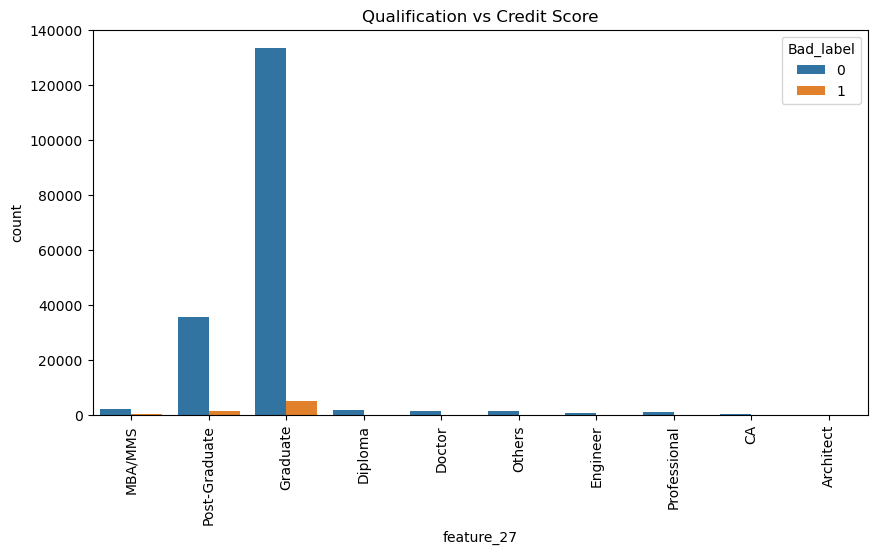

In [197]:
# checking qualification of the customer having what credit score

plt.figure(figsize=(10,5))
sns.countplot(x='feature_27', hue='Bad_label', data=data)
plt.title('Qualification vs Credit Score')
plt.xticks(rotation=90)
plt.show()

### Insights:- 

* The majority of customers hold **Graduate or Post-Graduate** qualifications, and most of them exhibit a good credit score.

* The occurrence of a **bad credit score** is relatively low among customers with Graduate, Post-Graduate, or professional degrees (MBA/MBBS), indicating a positive relationship between higher education levels and creditworthiness.

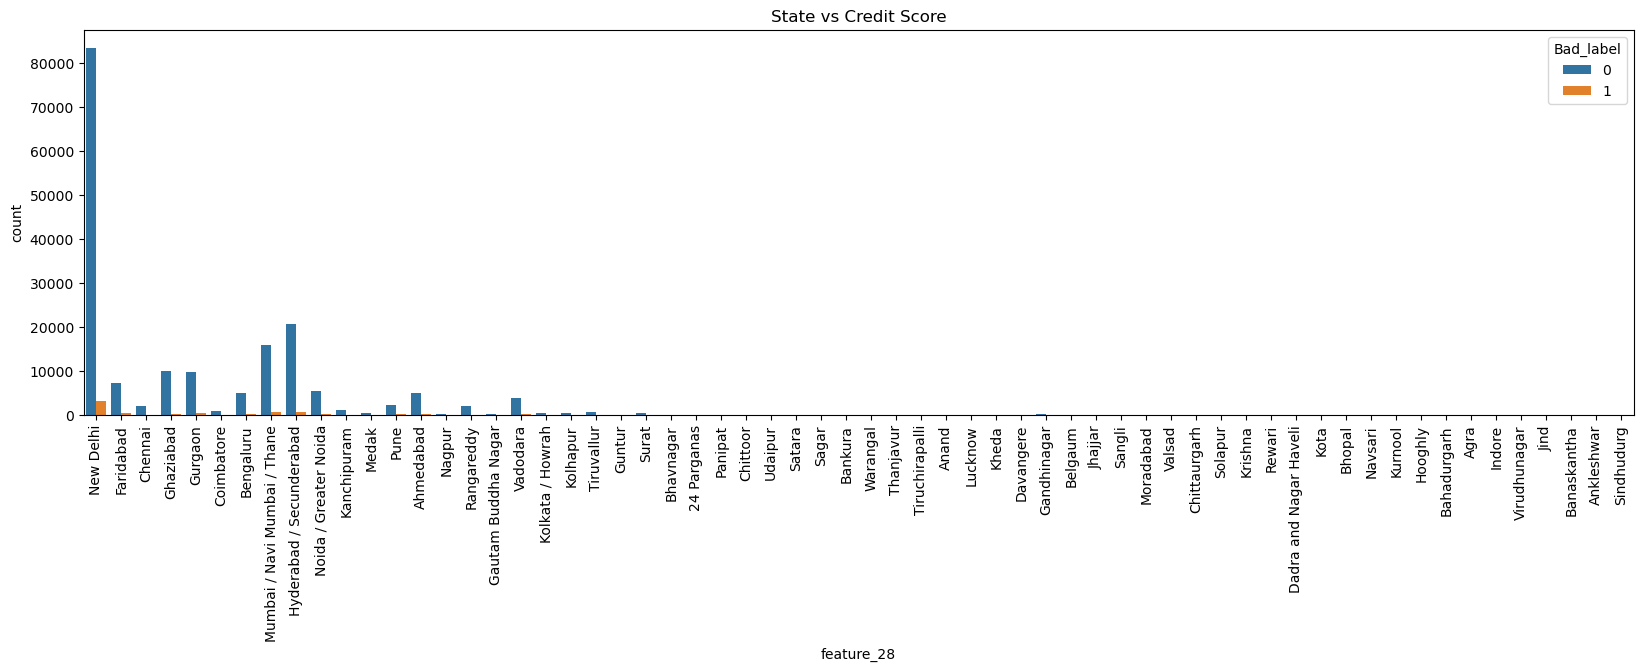

In [198]:
# checking state of the customer having what credit score

plt.figure(figsize=(20,5))
sns.countplot(x='feature_28', hue='Bad_label', data=data)
plt.title('State vs Credit Score')
plt.xticks(rotation=90)
plt.show()

#### Insights:- 

* A large proportion of customers are from **New Delhi** and **Hyderabad/Secunderabad**, and the majority of them have a good credit score.

* The likelihood of a **bad credit score** is significantly lower when compared to the number of customers with a good credit score, indicating an overall **healthy credit profile**.

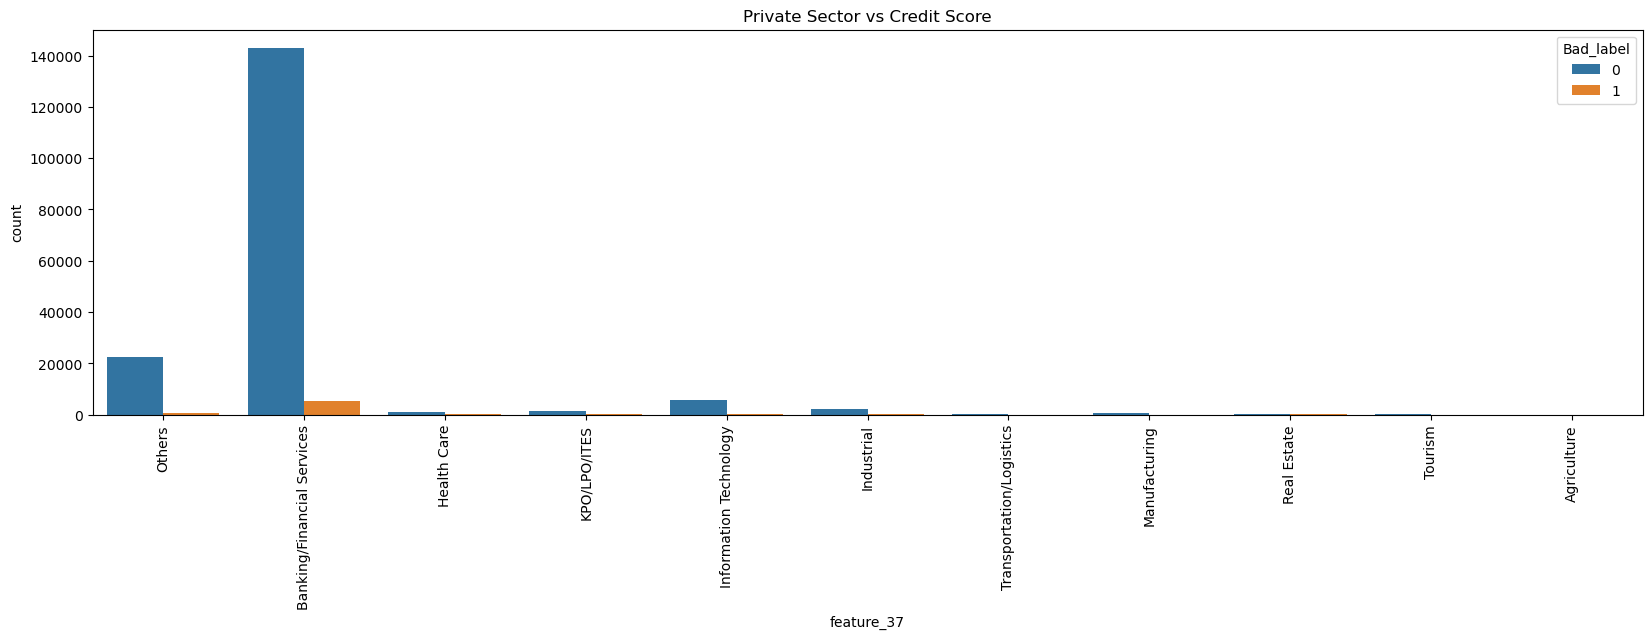

In [199]:
# checking visualization private sector vs credit score

plt.figure(figsize=(20,5))
sns.countplot(x='feature_37', hue='Bad_label', data=data)
plt.title('Private Sector vs Credit Score')

plt.xticks(rotation=90)
plt.show()

### Insights:- 

* Most customers belong to the **Banking/Financial Services** and **Other Services** sectors, and the majority of them have a **good credit score**, with only a small proportion exhibiting a bad credit score.

* A segment of customers comes from the **IT sector**, where—except for a few cases—most customers maintain a **good credit score**, indicating strong credit behavior within this group.

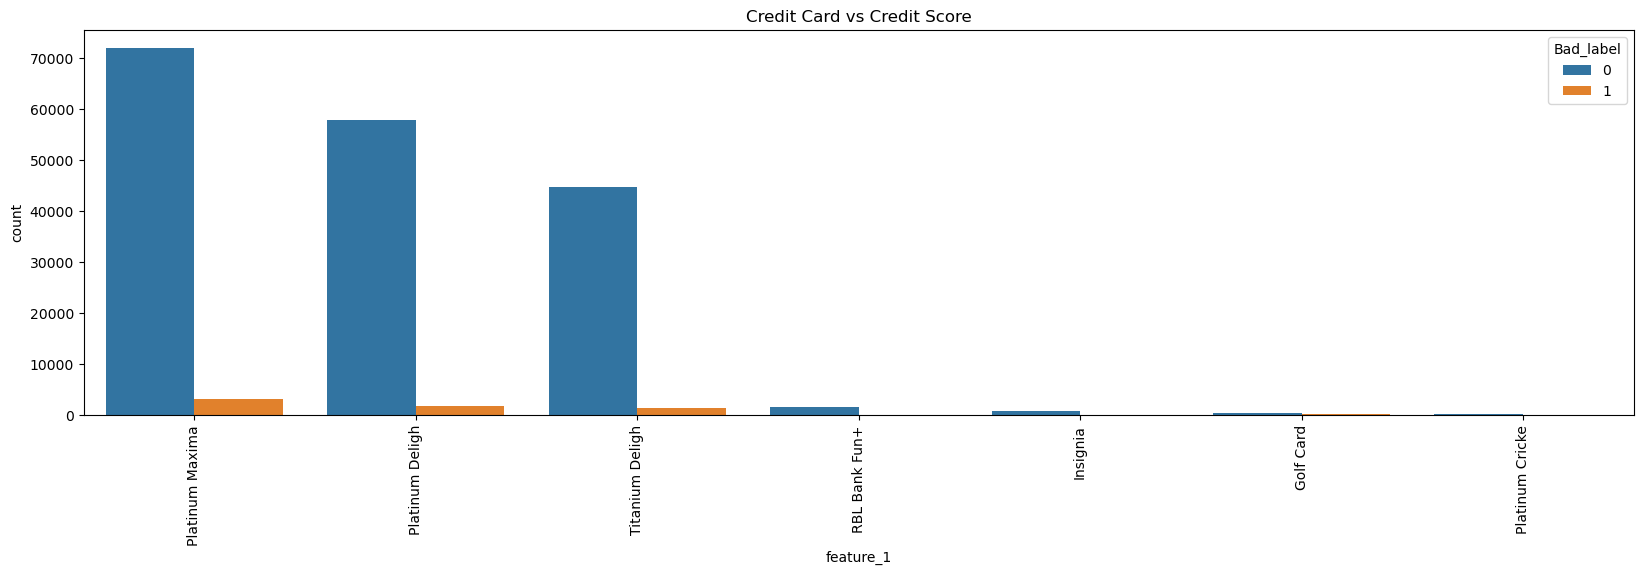

In [200]:
# checking credit card vs credit score

plt.figure(figsize=(20,5))
sns.countplot(x='feature_1', hue='Bad_label', data=data)
plt.title('Credit Card vs Credit Score')
plt.xticks(rotation=90)
plt.show()

### Insights:-

* The majority of customers hold **Platinum Maxima**, **Platinum Deligh**, or **Titanium Deligh** credit cards.

* Most customers across these card categories exhibit a **good credit score**.

* Customers associated with **RBL Bank**, **Insignia**, and **Platinum Cricke** credit cards predominantly maintain good credit scores, reflecting strong creditworthiness within these segments.

In [201]:
data.head(1)

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_23,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_43,feature_44,feature_50,feature_52,feature_55,feature_56,feature_58,feature_59,feature_60,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
0,12265,6,1,2013,20900.0,0,Platinum Maxima,683,3,56000.0,Y,PM1,12,SA05,MA01,1,N,1,0,MBA/MMS,New Delhi,110059.0,2006,0,Paren,Y,1,35000.0,Private Ltd. Co.,Others,SR EXE,1,4,0,Gurgaon,122001.0,N,0,1,10,N,Y,N,2006,10,157,110059.0,0,1,35000.0,13,R,0,1,1


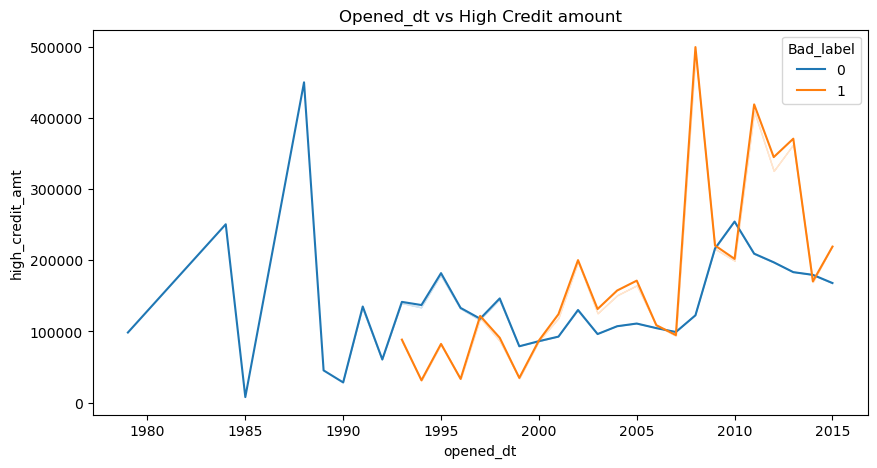

In [202]:
# checking opened_dt and high credit amount
plt.figure(figsize=(10,5))
sns.lineplot(x='opened_dt',y='high_credit_amt', hue='Bad_label', data=data,ci=False)
plt.title('Opened_dt vs High Credit amount')
plt.show()

### Insights:- 

* Customers with a **good credit score** generally show a **steady** and **stable** credit amount over the years.
* Customers with a **bad credit score** show large ups and downs in their credit amount, meaning their credit usage is **less consistent**.
* In some years, customers with a **bad credit score** have **higher credit amounts**, which may indicate **risky or uncontrolled** credit usage.
* Overall, customers with good credit scores manage their credit more smoothly, while bad credit score customers show unstable credit behavior.

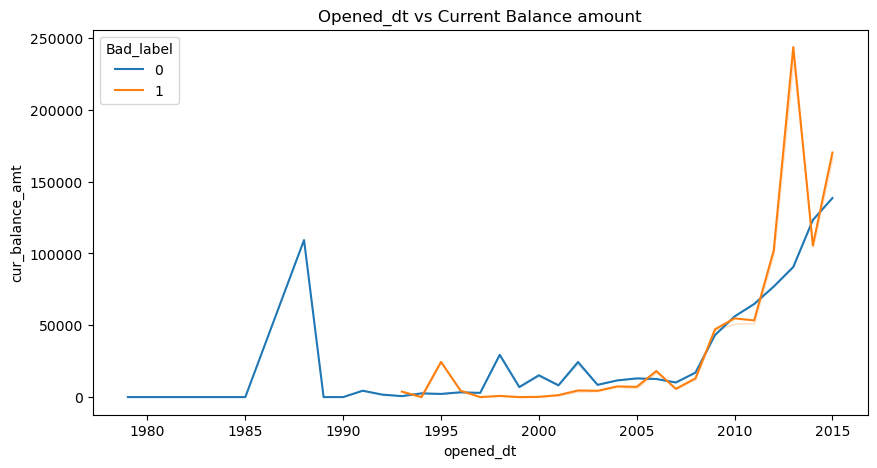

In [203]:
# checking opened_dt and current balance amount
plt.figure(figsize=(10,5))
sns.lineplot(x='opened_dt',y='cur_balance_amt', hue='Bad_label', data=data,ci=False)
plt.title('Opened_dt vs Current Balance amount')
plt.show()

### Insights:- 

* Customers with a **good credit score** generally have a lower and more stable **current balance** over time.
* Customers with a **bad credit score** show **sudden increases and sharp spikes** in their current balance, especially in recent years.
* In the later years, the **current balance of bad credit score customers becomes higher** than that of good credit score customers.
* Overall, **bad credit score** customers tend to carry higher outstanding balances, which may indicate **repayment difficulties or higher credit risk**.

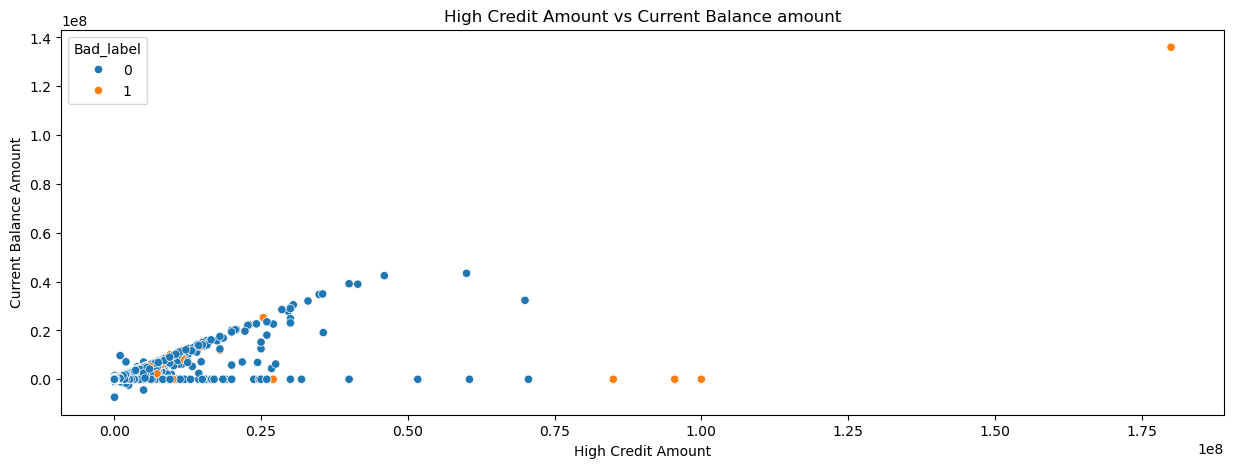

In [204]:
# high credit amount vs current balance amount

plt.figure(figsize=(15,5))
sns.scatterplot(x='high_credit_amt',y='cur_balance_amt', hue='Bad_label', data=data)
plt.title('High Credit Amount vs Current Balance amount')
plt.xlabel('High Credit Amount')
plt.ylabel('Current Balance Amount')
plt.show()

### Insights:-

* There is a positive relationship between high credit amount and current balance—as the credit limit increases, the balance generally increases.
* Customers with a good credit score are mostly clustered at lower to moderate credit and balance levels, showing controlled credit usage.
* Customers with a bad credit score appear as outliers, with very high credit amounts and balances, indicating higher financial risk.
* Overall, bad credit score customers tend to carry unusually high balances compared to good credit score customers.

## Checking for outliers:-

* As most of the columns are hide due to security purpose so checking outliers is not possible for every columns.
* There are only two columns which are having continuous values and their names are not hide so I'm checking the outliers only for them.

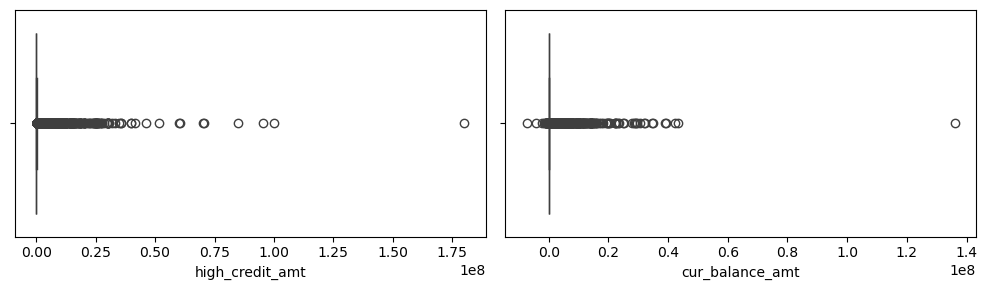

In [205]:
cols = ['high_credit_amt','cur_balance_amt']
plt.figure(figsize = (10,3))
plotnumber = 1
for i in cols:
    plt.subplot(1,2,plotnumber)
    sns.boxplot(x= data[i])
    plotnumber += 1
plt.tight_layout()
plt.show()

In [206]:
# Columns to check outliers
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_percentage = (len(outliers) / len(data)) * 100

    print(f'{col}: {outlier_percentage:.2f}% outliers')


high_credit_amt: 13.46% outliers
cur_balance_amt: 15.28% outliers


* Outliers are **high (>5%)**, so removing them may cause **data loss**
* High credit values can be valid business cases
* **Capping** keeps all records while reducing extreme impact.

In [207]:
# replacing extreme values with percentile thresolds(1st to 99th)
def iqr_capping(data, col):
    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
    return data

data = iqr_capping(data, 'high_credit_amt')
data = iqr_capping(data, 'cur_balance_amt')



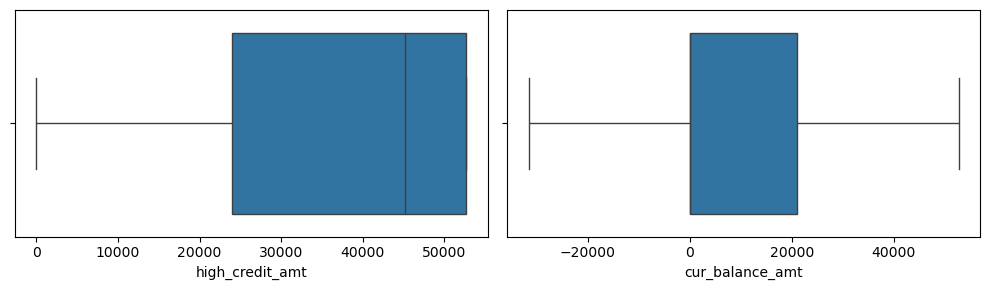

In [208]:
# as we can see that the all outlier are capped
cols = ['high_credit_amt','cur_balance_amt']
plt.figure(figsize = (10,3))
plotnumber = 1
for i in cols:
    plt.subplot(1,2,plotnumber)
    sns.boxplot(x= data[i])
    plotnumber += 1
plt.tight_layout()
plt.show()

In [209]:
data.head()

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_23,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_43,feature_44,feature_50,feature_52,feature_55,feature_56,feature_58,feature_59,feature_60,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
0,12265,6,1,2013,20900.00,0.0,Platinum Maxima,683,3,56000.0,Y,PM1,12,SA05,MA01,1,N,1,0,MBA/MMS,New Delhi,110059.0,2006,0,Paren,Y,1,35000.0,Private Ltd. Co.,Others,SR EXE,1,4,0,Gurgaon,122001.0,N,0,1,10,N,Y,N,2006,10,157,110059.0,0,1,35000.0,13,R,0,1,1
1,12265,10,1,2012,16201.00,10390.0,Platinum Maxima,683,3,56000.0,Y,PM1,12,SA05,MA01,1,N,1,0,MBA/MMS,New Delhi,110059.0,2006,0,Paren,Y,1,35000.0,Private Ltd. Co.,Others,SR EXE,1,4,0,Gurgaon,122001.0,N,0,1,10,N,Y,N,2006,10,157,110059.0,0,1,35000.0,13,R,0,1,1
2,12265,10,1,2012,41028.00,34420.0,Platinum Maxima,683,3,56000.0,Y,PM1,12,SA05,MA01,1,N,1,0,MBA/MMS,New Delhi,110059.0,2006,0,Paren,Y,1,35000.0,Private Ltd. Co.,Others,SR EXE,1,4,0,Gurgaon,122001.0,N,0,1,10,N,Y,N,2006,10,157,110059.0,0,1,35000.0,13,R,0,1,1
3,15606,10,1,2006,52666.25,0.0,Platinum Deligh,687,3,125000.0,Y,PD1,12,SA35,S001,1,N,1,2,Post-Graduate,Faridabad,121003.0,2009,0,Self,Y,1,100000.0,Private Ltd. Co.,Banking/Financial Services,GENRAL MANAGER OPERATIONS,1,2,0,Faridabad,121003.0,N,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,R,0,1,1
4,15606,6,1,2015,20250.00,13500.0,Platinum Deligh,687,3,125000.0,Y,PD1,12,SA35,S001,1,N,1,2,Post-Graduate,Faridabad,121003.0,2009,0,Self,Y,1,100000.0,Private Ltd. Co.,Banking/Financial Services,GENRAL MANAGER OPERATIONS,1,2,0,Faridabad,121003.0,N,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,R,0,1,1


## Conversion of Categorical Columns

##### **feature_1**

In [210]:
data['feature_1'].value_counts()

feature_1
Platinum Maxima    74978
Platinum Deligh    59682
Titanium Deligh    46016
RBL Bank Fun+       1644
Insignia             865
Golf Card            403
Platinum Cricke      303
Name: count, dtype: int64

In [211]:
# manually converting the categorical columns

data['feature_1'] = data.feature_1.replace({'Platinum Maxima':1,'Platinum Deligh':2,'Titanium Deligh':3,'RBL Bank Fun+':4,'Insignia':5,
                                           'Golf Card':6,'Platinum Cricke':7})

##### **feature_11**

In [212]:
data['feature_11'].value_counts()

feature_11
Y    175543
N      8348
Name: count, dtype: int64

In [213]:
data['feature_11'] = data.feature_11.replace({'Y':1,'N':0})

### Label Encoder:-

In [214]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data.feature_12 = le.fit_transform(data.feature_12)
data.feature_15 = le.fit_transform(data.feature_15)
data.feature_16 = le.fit_transform(data.feature_16)
data.feature_27 = le.fit_transform(data.feature_27)
data.feature_28 = le.fit_transform(data.feature_28)
data.feature_32 = le.fit_transform(data.feature_32)
data.feature_36 = le.fit_transform(data.feature_36)
data.feature_37 = le.fit_transform(data.feature_37)
data.feature_38 = le.fit_transform(data.feature_38)
data.feature_50 = le.fit_transform(data.feature_50)
data.feature_72 = le.fit_transform(data.feature_72)

In [215]:
data.head(10)

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_23,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_43,feature_44,feature_50,feature_52,feature_55,feature_56,feature_58,feature_59,feature_60,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
0,12265,6,1,2013,20900.00,0.00,1,683,3,56000.0,1,10,12,303,360,1,N,1,0,6,42,110059.0,2006,0,2,Y,1,35000.0,6,7,4509,1,4,0,Gurgaon,122001.0,0,0,1,10,N,Y,N,2006,10,157,110059.0,0,1,35000.0,13,1,0,1,1
1,12265,10,1,2012,16201.00,10390.00,1,683,3,56000.0,1,10,12,303,360,1,N,1,0,6,42,110059.0,2006,0,2,Y,1,35000.0,6,7,4509,1,4,0,Gurgaon,122001.0,0,0,1,10,N,Y,N,2006,10,157,110059.0,0,1,35000.0,13,1,0,1,1
2,12265,10,1,2012,41028.00,34420.00,1,683,3,56000.0,1,10,12,303,360,1,N,1,0,6,42,110059.0,2006,0,2,Y,1,35000.0,6,7,4509,1,4,0,Gurgaon,122001.0,0,0,1,10,N,Y,N,2006,10,157,110059.0,0,1,35000.0,13,1,0,1,1
3,15606,10,1,2006,52666.25,0.00,2,687,3,125000.0,1,7,12,322,427,1,N,1,2,8,18,121003.0,2009,0,4,Y,1,100000.0,6,1,2019,1,2,0,Faridabad,121003.0,0,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,1,0,1,1
4,15606,6,1,2015,20250.00,13500.00,2,687,3,125000.0,1,7,12,322,427,1,N,1,2,8,18,121003.0,2009,0,4,Y,1,100000.0,6,1,2019,1,2,0,Faridabad,121003.0,0,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,1,0,1,1
5,15606,6,1,2015,20000.00,8000.00,2,687,3,125000.0,1,7,12,322,427,1,N,1,2,8,18,121003.0,2009,0,4,Y,1,100000.0,6,1,2019,1,2,0,Faridabad,121003.0,0,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,1,0,1,1
6,15606,6,1,2014,25100.00,12550.00,2,687,3,125000.0,1,7,12,322,427,1,N,1,2,8,18,121003.0,2009,0,4,Y,1,100000.0,6,1,2019,1,2,0,Faridabad,121003.0,0,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,1,0,1,1
7,15606,6,1,2014,16690.00,2780.00,2,687,3,125000.0,1,7,12,322,427,1,N,1,2,8,18,121003.0,2009,0,4,Y,1,100000.0,6,1,2019,1,2,0,Faridabad,121003.0,0,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,1,0,1,1
8,15606,10,1,2012,52666.25,52666.25,2,687,3,125000.0,1,7,12,322,427,1,N,1,2,8,18,121003.0,2009,0,4,Y,1,100000.0,6,1,2019,1,2,0,Faridabad,121003.0,0,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,1,0,1,1
9,15606,10,1,2012,45212.00,26879.00,2,687,3,125000.0,1,7,12,322,427,1,N,1,2,8,18,121003.0,2009,0,4,Y,1,100000.0,6,1,2019,1,2,0,Faridabad,121003.0,0,0,1,13,N,Y,N,2009,13,39,121003.0,0,1,100000.0,13,1,0,1,1


In [216]:
## the columns which have constant value for all records i'm going to drop that columns

data.drop(['feature_23','feature_33','feature_58','feature_59','feature_60'],axis=1,inplace = True)

In [217]:
# feature_43 and feature 28 giving same information so i'm going to drop feature_43

data.drop('feature_43',inplace=True,axis=1)

In [218]:
data.sample(10)

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_44,feature_50,feature_52,feature_55,feature_56,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_76,feature_78,Bad_label
159393,17743,6,1,2013,28510.00,0.0,2,724,3,340000.0,1,7,12,301,133,2,1,0,5,42,110018.0,1990,0,4,2,1.0,6,1,2629,0,0,0,110018.0,1,283000,3,10,1990,10,157,110018.0,0,2,1.0,10,1,0,1,0
33482,13644,6,1,2014,26990.00,0.0,1,742,1,55000.0,1,10,12,235,236,1,2,0,8,39,400057.0,1985,0,2,1,30000.0,8,7,5120,2,7,0,400053.0,1,55000,1,21,1985,21,15,400057.0,0,1,30000.0,21,1,0,1,0
163155,15918,10,1,2012,52666.25,15132.0,2,739,3,124000.0,1,7,12,301,126,1,1,4,5,23,122001.0,1980,0,4,2,1.0,6,1,2629,0,0,0,122001.0,1,80000,1,13,1980,13,3,122001.0,0,2,1.0,13,1,0,1,0
138200,18265,10,1,2005,4027.00,0.0,2,798,3,30000.0,1,7,12,338,198,1,1,3,5,21,201014.0,2013,0,4,1,100000.0,6,1,541,8,11,0,201309.0,0,0,1,33,2013,33,41,201014.0,0,1,100000.0,33,1,0,1,0
132958,9145,10,1,2004,45212.00,0.0,1,779,3,248000.0,1,10,12,301,138,1,1,0,5,23,122017.0,2015,0,4,1,1.0,8,1,2011,0,11,0,110001.0,1,175000,1,13,2015,13,3,122017.0,0,1,1.0,10,1,0,1,0
101923,4597,7,1,2014,52666.25,0.0,3,713,1,188000.0,1,14,0,110,303,1,2,0,5,9,560056.0,2010,0,3,1,27000.0,6,1,1935,5,2,5,560011.0,1,156000,1,17,2010,17,12,560056.0,0,1,27000.0,17,0,0,1,0
175258,16068,6,1,2009,15000.00,0.0,2,805,1,137000.0,1,7,12,220,411,1,1,2,5,2,382405.0,2013,0,4,1,1.0,8,5,2876,7,11,0,382405.0,1,105000,1,12,2013,12,8,382405.0,0,1,1.0,12,1,0,1,0
12460,7655,10,1,2007,15304.00,0.0,1,768,3,154000.0,1,10,12,110,309,1,1,2,5,9,560027.0,2012,0,3,1,51134.0,6,1,3620,11,6,0,560045.0,0,0,1,17,2012,17,12,560027.0,0,1,51134.0,17,0,0,1,0
152077,19296,10,1,2007,101.00,0.0,2,750,1,239000.0,1,7,12,301,137,1,1,0,5,42,110024.0,1975,0,4,2,1.0,6,1,2629,0,0,0,110024.0,0,0,1,10,1975,10,157,110024.0,0,2,1.0,10,1,0,1,0
54216,4796,10,1,2003,52666.25,0.0,3,748,1,30000.0,1,14,0,229,10,1,1,0,5,39,400102.0,2003,0,4,2,100000.0,6,1,2629,0,0,0,400102.0,0,0,1,21,2003,21,15,400102.0,0,2,100000.0,21,0,0,1,0


## Feature Selection

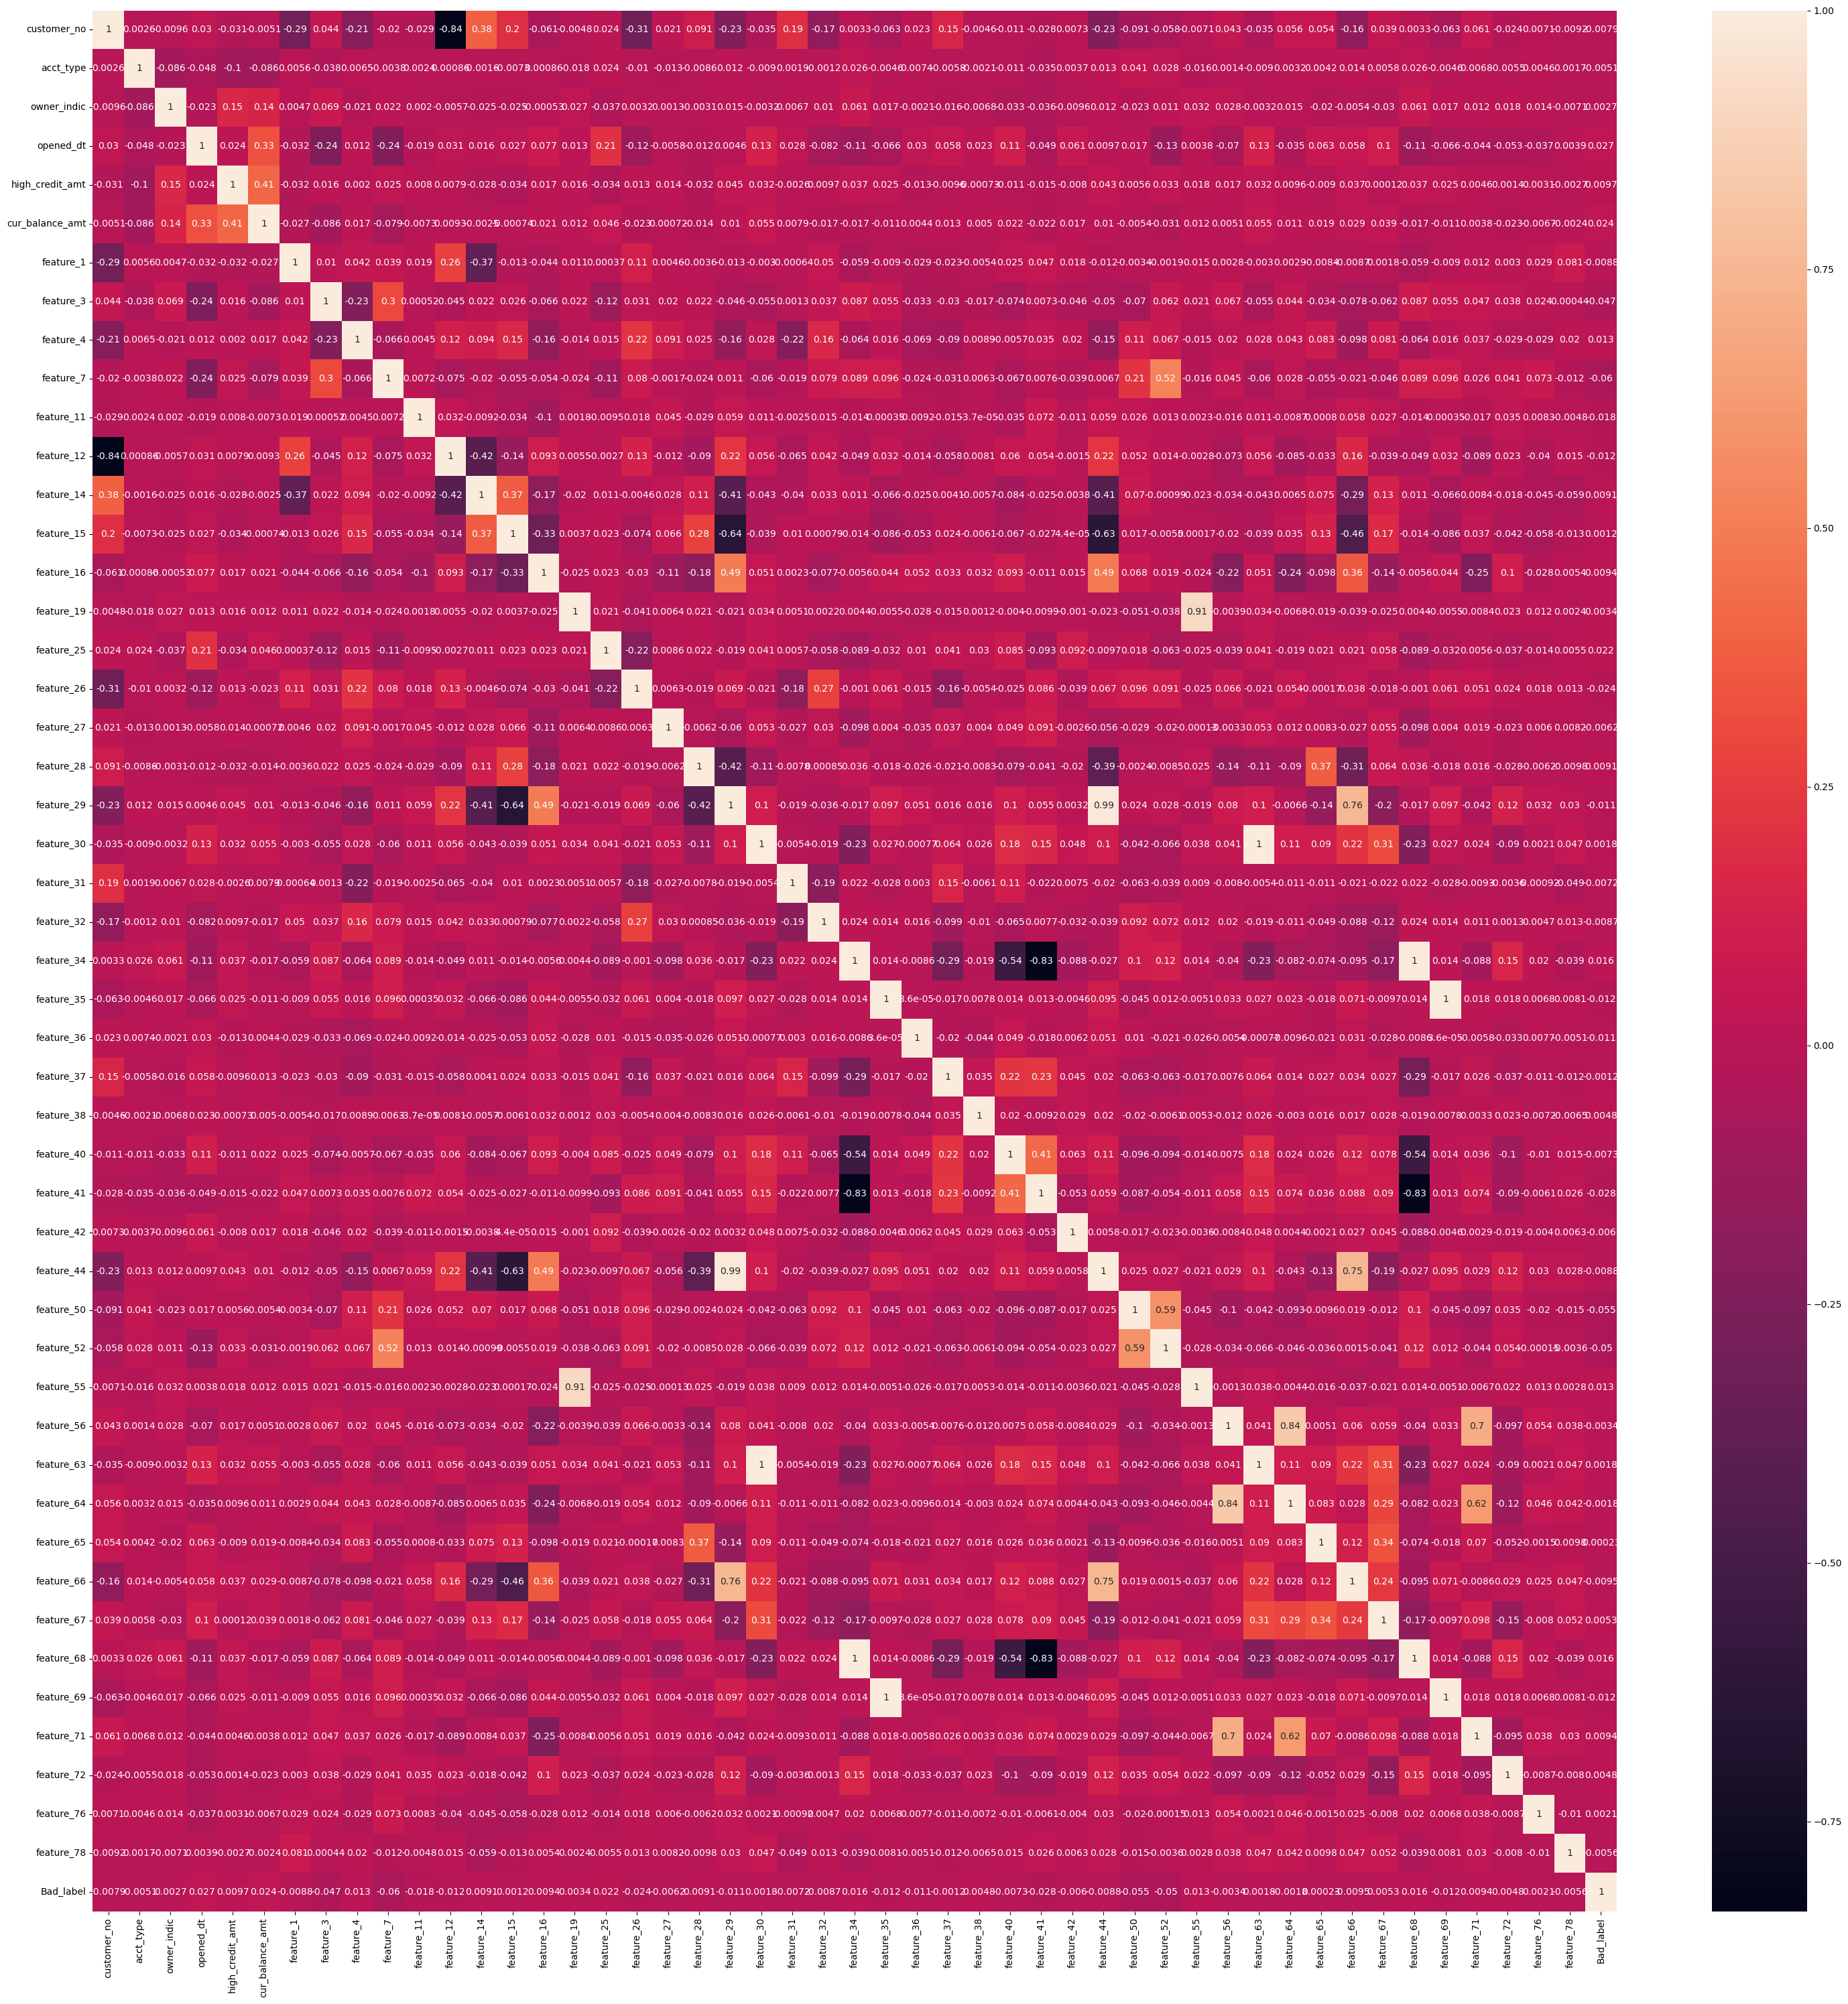

In [219]:
# checking multicollinearity between the columns

plt.figure(figsize= (30,30))
sns.heatmap(data.corr(),annot=True)
plt.tight_layout()
plt.show()

The Below columns are highly correlated with the input columns.
* **feature_55 and feature 19**
* **feature_44 and feature_29**
* **feature_63 and feature_30**
* **feature_68 and feature_34**
* **feature_69 and feature_35**

So, I'm going to drop one of them .

In [220]:
data.drop(['feature_55','feature_44','feature_63','feature_68','feature_69'],axis=1,inplace=True)

In [221]:
data.sample(10)

,customer_no,acct_type,owner_indic,opened_dt,high_credit_amt,cur_balance_amt,feature_1,feature_3,feature_4,feature_7,feature_11,feature_12,feature_14,feature_15,feature_16,feature_19,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_34,feature_35,feature_36,feature_37,feature_38,feature_40,feature_41,feature_42,feature_50,feature_52,feature_56,feature_64,feature_65,feature_66,feature_67,feature_71,feature_72,feature_76,feature_78,Bad_label
69084,1887,5,1,2013,52666.25,0.00,3,740,3,136000.0,1,14,12,301,123,1,1,0,5,21,201005.0,2005,0,4,1,40000.0,1,1,624,2,7,0,1,100000,33,33,41,201005.0,0,33,1,0,1,1
177300,15838,10,1,2006,21145.00,-2.00,2,733,3,390000.0,1,7,12,301,123,1,1,0,8,42,110093.0,2005,0,4,1,1.0,8,1,3780,1,10,0,1,600000,10,10,157,110093.0,0,10,1,0,1,0
115743,7352,10,1,2007,52666.25,0.00,1,738,3,101000.0,1,10,12,189,458,1,2,1,8,25,500062.0,2008,0,4,1,66920.0,6,4,1222,10,7,0,0,0,2,2,14,500062.0,0,2,1,0,1,0
65685,23741,10,1,2013,52666.25,52666.25,4,715,1,400000.0,1,6,0,2,231,1,1,0,8,21,201011.0,2006,5,4,1,146425.0,8,1,5590,4,10,0,0,0,33,33,41,201011.0,0,10,0,0,1,0
175278,11878,10,1,2015,15599.00,0.00,1,747,1,124000.0,1,10,12,200,150,1,1,0,5,9,560037.0,2013,0,3,1,27000.0,6,1,2629,8,6,0,0,0,17,17,12,560037.0,0,17,1,0,1,0
137361,14108,2,4,2007,52666.25,0.00,1,689,1,217000.0,1,10,12,185,503,1,1,0,8,25,500050.0,2000,3,4,1,38000.0,6,7,2100,3,11,0,1,217000,2,2,14,500050.0,0,2,1,0,1,0
22061,338,6,1,2014,15000.00,4500.00,3,784,3,237000.0,1,14,12,301,126,1,1,1,5,42,110017.0,1987,0,4,2,70000.0,6,1,2629,0,0,0,1,260000,10,10,157,110017.0,0,10,1,0,1,0
74430,4670,6,1,2012,22340.00,17780.00,3,704,3,89000.0,1,14,0,301,138,1,1,0,5,42,110031.0,1995,0,4,2,1.0,6,1,2629,0,0,0,0,0,10,10,157,110031.0,0,10,0,0,1,0
121323,11119,10,1,2013,27871.00,-28.00,1,724,3,35000.0,1,11,0,158,40,1,1,0,5,7,700036.0,2000,0,2,1,24450.0,8,1,3628,4,6,0,0,0,35,35,466,700036.0,0,35,1,0,1,0
109165,13216,6,1,2014,36051.00,0.00,1,675,3,89000.0,1,10,12,236,260,1,1,0,5,39,400067.0,2009,0,2,1,58733.0,6,1,4653,1,11,0,0,0,21,21,15,400067.0,0,21,1,0,1,0


## Splitting tha data into x and y

In [222]:
x = data.drop('Bad_label',axis=1)
y= data['Bad_label']

In [223]:
# checking the data is balanced or not

data['Bad_label'].value_counts()

Bad_label
0    177411
1      6480
Name: count, dtype: int64

In [224]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=1)

In [225]:
x_train.shape

(137918, 43)

In [226]:
# as we ccan see that the data is not balanced so we need to balanced the data using SMOTE

from imblearn.over_sampling import SMOTE        # importing the SMOTE to handle the unbalanced data
sm = SMOTE()             # initialize the model
x_smote,y_smote = sm.fit_resample(x_train,y_train)   # fit the ddata to balanced

In [227]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_smote))

Counter({0: 133053, 1: 4865})
Counter({0: 133053, 1: 133053})


# Model Selection

## Logistic Regression

In [228]:
# importing the logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()   # Initialize the model
lr.fit(x_smote,y_smote)    # Fitting the dataset into the model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [229]:
# model prediction

lr_pred = lr.predict(x_test)
lr_pred

array([1, 0, 1, ..., 1, 0, 0], shape=(45973,))

In [230]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
lr_acc = accuracy_score(y_test,lr_pred)
lr_f1 = f1_score(y_test,lr_pred,average="weighted")


In [231]:
lr_acc

0.5061666630413504

In [232]:
lr_f1

0.6412725142983959

In [233]:
confusion_matrix(y_test,lr_pred)

array([[22175, 22183],
       [  520,  1095]])

### HyperParameterr Tuning

##### RandomizedSearchCV

* RandomizedSearchCV was used to efficiently tune Logistic Regression hyperparameters and optimize weighted F1-score for imbalanced credit risk data.

In [234]:
# Import required libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score,accuracy_score


# Define hyperparameter distributions
param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],   # Regularization strength values
    'penalty': ['l1', 'l2'],              # Regularization types
    'solver': ['liblinear'],              # Solver supporting l1 and l2
    'class_weight': [None, 'balanced']    # Handle class imbalance
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lr,        # Model to tune
    param_distributions=param_dist,  # Parameter distributions
    n_iter=20,                # Number of random combinations to try
    scoring='f1_weighted',    # Evaluation metric
    verbose = 2,              # Printing statement
    cv=2,                     # 5-fold cross-validation
    random_state=42,          # Reproducibility
    n_jobs=-1                 # Use all CPU cores
)

# Fit RandomizedSearchCV on training data
random_search.fit(x_train, y_train)

# Get the best tuned model
best_log_reg = random_search.best_estimator_

# Print best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)


Fitting 2 folds for each of 20 candidates, totalling 40 fits
Best Hyperparameters: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': None, 'C': 0.001}


In [234]:
# Build model with the best hyperparameters

lr1 = LogisticRegression(solver='liblinear',penalty = 'l1',class_weight=None,C=0.001)
lr1.fit(x_smote,y_smote)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [235]:
# prediction

lr1_pred = lr1.predict(x_test)
lr1_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [236]:
lr1_acc_hy = accuracy_score(y_test,lr1_pred)
lr1_f1_hy = f1_score(y_test,lr1_pred,average='weighted')

In [237]:
lr1_acc_hy

0.6734170056337415

In [238]:
lr1_f1_hy

0.7759209616765746

In [239]:
print(classification_report(y_test,lr1_pred))

              precision    recall  f1-score   support

           0       0.97      0.68      0.80     44358
           1       0.05      0.51      0.10      1615

    accuracy                           0.67     45973
   macro avg       0.51      0.59      0.45     45973
weighted avg       0.94      0.67      0.78     45973



## Random Forest 

In [240]:
# importing random forest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators= 250)    # initialize the model
rf.fit(x_smote,y_smote)     # fit the data into the model

,n_estimators,250
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [241]:
## predicting

rf_pred = rf.predict(x_test)
rf_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [243]:
## Checking accuraccy
rf_acc = accuracy_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred,average="weighted")

In [244]:
rf_acc

0.9943227546603441

In [245]:
rf_f1

0.9941271948156277

In [246]:
confusion_matrix(y_test,rf_pred)

array([[44335,    23],
       [  238,  1377]])

In [247]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     44358
           1       0.98      0.85      0.91      1615

    accuracy                           0.99     45973
   macro avg       0.99      0.93      0.96     45973
weighted avg       0.99      0.99      0.99     45973



* **Since the RandomForest Classifier model delivered a high accuracy of 99.40% without hyperparameter tuning, additional tuning was considered unnecessary.**

## KNN

In [248]:
# importing K Nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)     # initialize the model with 5 nearest neighbors
knn.fit(x_smote,y_smote)       # fitting the data into the model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [249]:
# Predicting the model

knn_pred = knn.predict(x_test)
knn_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [250]:
knn_acc = accuracy_score(y_test,knn_pred)
knn_f1 = f1_score(y_test,knn_pred,average="weighted")

In [251]:
knn_acc

0.9054662519304809

In [252]:
knn_f1

0.9280504159994302

In [253]:
# checking the lowest error rate at how many neighbors
error_rate = []     # storing all error rate 

for i in range(1,10): # checking 1 to 10 neighors
    KNN = KNeighborsClassifier(n_neighbors=i)    # inintialize the model
    KNN.fit(x_smote,y_smote)      # fit the data into the model
    KNN_pred = KNN.predict(x_test)     # predicting
    error_rate.append(np.mean(KNN_pred != y_test))    # appending the error in error rate 

In [254]:
# printing the all the error
error_rate

[np.float64(0.04844147651882627),
 np.float64(0.045156939943010024),
 np.float64(0.07502229569529942),
 np.float64(0.06899701998999412),
 np.float64(0.09453374806951907),
 np.float64(0.08874774324059774),
 np.float64(0.1109129271528941),
 np.float64(0.10449611728623322),
 np.float64(0.12342026841841951)]

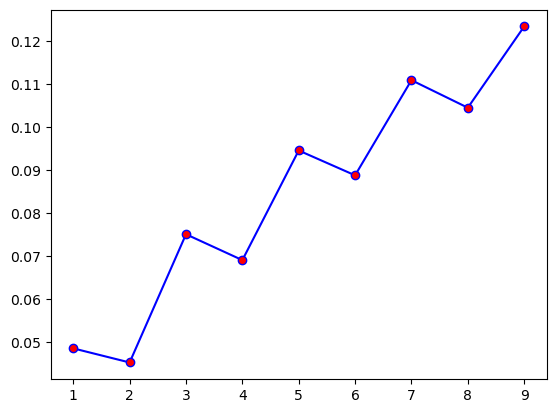

In [255]:
# plotting the error and check at which neighbor the error is very low
plt.plot(range(1,10),error_rate,color='blue',marker='o',markerfacecolor='red')

In [256]:
# as wee can see that that at 3 neigbors the error is low 
# importing K Nearest neighbors
from sklearn.neighbors import KNeighborsClassifier
knn1 = KNeighborsClassifier(n_neighbors = 3)     # initialize the model with 5 nearest neighbors
knn1.fit(x_smote,y_smote)       # fitting the data into the model

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [257]:
knn1_pred = knn1.predict(x_test)
knn1_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [261]:
knn1_acc = accuracy_score(y_test,knn1_pred)
knn1_f1 = f1_score(y_test,knn1_pred,average='weighted')

In [262]:
knn1_acc

0.9249777043047006

In [263]:
knn1_f1

0.9403303524005587

In [264]:
confusion_matrix(y_test,knn1_pred)

array([[41372,  2986],
       [  463,  1152]])

In [265]:
print(classification_report(y_test,knn1_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     44358
           1       0.28      0.71      0.40      1615

    accuracy                           0.92     45973
   macro avg       0.63      0.82      0.68     45973
weighted avg       0.96      0.92      0.94     45973



## Decision Tree

In [266]:
# importing decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=47)     # initialize the model
dt.fit(x_smote,y_smote)    # fitting the data into the model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,47
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [267]:
# predicting the model
dt_pred = dt.predict(x_test)
dt_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [271]:
# cehcking the accuracy
dt_acc = accuracy_score(y_test,dt_pred)
dt_f1 = f1_score(y_test,dt_pred,average="weighted")

In [272]:
dt_acc

0.9662193026341548

In [273]:
dt_f1

0.9695220821095256

In [274]:
confusion_matrix(y_test,dt_pred)

array([[43165,  1193],
       [  360,  1255]])

In [275]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     44358
           1       0.51      0.78      0.62      1615

    accuracy                           0.97     45973
   macro avg       0.75      0.88      0.80     45973
weighted avg       0.97      0.97      0.97     45973



### HyperParameter Tuning

In [270]:
## crearing dictionary for hyperparameters
from sklearn.model_selection import RandomizedSearchCV
params = {'criterion':('gini','entropy'),          # Methods to measure quality of a split
         'splitter':('random','best'),             # To choose split at each node
         'max_depth':(list(range(1,30))),          # Maximum height of the tree
         'min_samples_split':[2,5,7,10],           # Minimum samples required to split an internal node
         'min_samples_leaf':list(range(1,20))}     # Minimum samples required in a leaf node

tree_clf = DecisionTreeClassifier(random_state=9)
tree_hy = RandomizedSearchCV(tree_clf,params,scoring='accuracy',n_jobs=-1,verbose=2,cv=3)       ## Initialize the GridSearchCV


# verbose=2 = show training progress in a clean, readable way.
#n_jobs = -1 =  use all CPU cores to make training faster.

tree_hy.fit(x_smote,y_smote)                    ## fit a data for hyperparameter tuning
best_params = tree_hy.best_params_             ## Best Parameters given by using hyperparameter tuning
print(f"Best Parameters: {best_params}")       ## Printing the best parameters  

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'splitter': 'best', 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_depth': 29, 'criterion': 'entropy'}


In [276]:
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=29,min_samples_split=7,min_samples_leaf=6,splitter='best')
dt1.fit(x_smote,y_smote)

,criterion,'entropy'
,splitter,'best'
,max_depth,29
,min_samples_split,7
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [277]:
## Prediction
dt_pred1 = dt1.predict(x_test)
dt_pred1

array([1, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [278]:
## checking accuracy by using hyperparameter tuning
dt_acc_hy = accuracy_score(y_test,dt_pred1)
dt_acc_hy

0.9575402953907729

In [279]:
## checking f1 score for hyperparameter tuning
dt_f1_hy = f1_score(y_test,dt_pred1,average='weighted')
dt_f1_hy

0.9620465968352536

## Gradient Boosting

In [280]:
# importing Grdient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators = 250)    # initialize the model with 250 estimators
gb.fit(x_smote,y_smote)      # fitting the data into the model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,250
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [281]:
## Predicting the model

gb_pred = gb.predict(x_test)
gb_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [282]:
# checking the accuracy
gb_acc = accuracy_score(y_test,gb_pred)
gb_f1 = f1_score(y_test,gb_pred,average="weighted")

In [283]:
gb_acc

0.889369847519196

In [284]:
gb_f1

0.9140229994568192

In [285]:
confusion_matrix(y_test,gb_pred)

array([[40321,  4037],
       [ 1049,   566]])

In [286]:
print(classification_report(y_test,gb_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94     44358
           1       0.12      0.35      0.18      1615

    accuracy                           0.89     45973
   macro avg       0.55      0.63      0.56     45973
weighted avg       0.94      0.89      0.91     45973



### HyperParameter Tuning

In [282]:
## creating dictionary for hyperparameters
gb_grid = {'learning_rate':[0.01,0.03,0.1],
          'max_depth':[5,6,7],
          'n_estimators':[50,65,80]}

gb1 = GradientBoostingClassifier(random_state=82)
gb_hy = RandomizedSearchCV(estimator=gb1,scoring='accuracy',param_distributions=gb_grid,n_iter=20,cv=2,verbose=2,random_state=42,n_jobs=-1)

gb_hy.fit(x_smote,y_smote)
gb_best_params = gb_hy.best_params_
print('Best Parameters: ',gb_best_params)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
Best Parameters:  {'n_estimators': 65, 'max_depth': 7, 'learning_rate': 0.1}


In [287]:
# build the model with the best hyperparameter
gb3 = GradientBoostingClassifier(n_estimators=65,max_depth=7,learning_rate=0.1)
gb3.fit(x_smote,y_smote)     # fit the data into the model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,65
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,7
,min_impurity_decrease,0.0
,init,None


In [288]:
# Predicting
gb3_pred = gb3.predict(x_test)
gb3_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [289]:
gb_acc_hy = accuracy_score(y_test,gb3_pred)
gb_acc_hy

0.9370282557153111

In [290]:
gb_f1_hy = f1_score(y_test,gb3_pred,average='weighted')
gb_f1_hy

0.9450042586134387

## XGBoost

In [291]:
# importing XGBClassifier
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators = 300)      # initialize the model
xgb.fit(x_smote,y_smote)       # fitting the data into the model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [292]:
xgb_pred = xgb.predict(x_test)
xgb_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [296]:
# checking the accuracy
xgb_acc = accuracy_score(y_test,xgb_pred)
xgb_f1 = f1_score(y_test,xgb_pred,average="weighted")

In [297]:
xgb_acc

0.9955626128379701

In [298]:
xgb_f1

0.9954480290634077

In [299]:
confusion_matrix(y_test,xgb_pred)

array([[44338,    20],
       [  184,  1431]])

In [300]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44358
           1       0.99      0.89      0.93      1615

    accuracy                           1.00     45973
   macro avg       0.99      0.94      0.97     45973
weighted avg       1.00      1.00      1.00     45973



* **Since the XGBoost model delivered a high accuracy of 99.76% without hyperparameter tuning, additional tuning was considered unnecessary.**

## ANN

In [301]:
from sklearn.neural_network import MLPClassifier   # Import MLPClassifier for building an Artificial Neural Network

# Initialize the ANN model with specified parameters
ann = MLPClassifier(
    hidden_layer_sizes=(200, 100, 50),   # Define 3 hidden layers with 200, 100, and 50 neurons respectively
    learning_rate_init=0.01,             # Set the initial learning rate for weight updates
    max_iter=200,                        # Set the maximum number of training iterations (epochs)
    random_state=0                       # Set random state for reproducibility of results
)

# Train the ANN model using SMOTE-balanced training data
ann.fit(x_smote, y_smote)


,hidden_layer_sizes,"(200, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,0


In [302]:
# Prediction

ann_pred = ann.predict(x_test)
ann_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(45973,))

In [303]:
# train data prediction
ann_train_pred = ann.predict(x_train)

In [311]:
# checking accuracy and f1 score
ann_acc = accuracy_score(y_test,ann_pred)
ann_f1 = f1_score(y_test,ann_pred,average='weighted')

In [312]:
ann_acc

0.9648706849672634

In [313]:
ann_f1

0.9476200605280107

# Model Comparison

In [314]:
# creating model comparison report using DataFrame
score = pd.DataFrame({"Models":["LogisticRegression","RandomForestClassifier","KNeighborsClassifier","DecisionTreeClassifier",'XG Boost','GradientBoosting',"ANN"],
                     "Accuracy":[lr_acc*100,rf_acc*100,knn_acc*100,dt_acc*100,xgb_acc*100,gb_acc*100,ann_acc*100],
                      "f1_score":[lr_f1*100,rf_f1*100,knn_f1*100,dt_f1*100,xgb_f1,gb_f1*100,ann_f1*100],
                     "With Hyperparameter Tunning":[lr1_acc_hy,'Not Required',knn1_acc*100,dt_acc_hy*100,'Not Required',gb_acc_hy*100,'-']
                     })

In [315]:
score

,Models,Accuracy,f1_score,With Hyperparameter Tunning
0,LogisticRegression,50.616666,64.127251,0.673417
1,RandomForestClassifier,99.432275,99.412719,Not Required
2,KNeighborsClassifier,90.546625,92.805042,92.49777
3,DecisionTreeClassifier,96.621930,96.952208,95.75403
4,XG Boost,99.556261,0.995448,Not Required
5,GradientBoosting,88.936985,91.402300,93.702826
6,ANN,96.487068,94.762006,-


# Model Comparison Report

A total of seven machine learning models were evaluated in this study, including Logistic Regression, Random Forest, K-Nearest Neighbors, Decision Tree, XGBoost, Gradient Boosting, and Artificial Neural Network (ANN). Based on accuracy and F1-score comparison, **XGBoost was selected as the final model**, as it achieved the **highest accuracy (99.56%)** and **F1-score (99.54%)** without hyperparameter tuning. The model showed strong robustness, handled class imbalance effectively, and generalized well compared to the other approaches.

Hyperparameter tuning was **not applied to some models**, such as **Random Forest** and **XGBoost**, because they already delivered **excellent performance with default parameters**. Applying further tuning in these cases was unlikely to result in significant improvement and would increase computational cost without meaningful gains, so the models were retained in their default configurations for efficiency and simplicity.

# Data Analysis Report 

This project focuses on building a **machine learning model to classify bank customers based on their credit score (Good or Bad)**. The dataset consists of **three related tables**: *Customer Enquiry details*, *Customer Demographics*, and *Customer Account information*. The project was carried out in multiple stages, including **data exploration**, **data preprocessing**, **model building**, and **model evaluation**.

During the **data exploration** phase, the dataset was analyzed to understand its structure and quality. It was observed that the **target variable was highly imbalanced**, and several features contained a **large number of missing values**. Some columns also had **incorrect data types**, and many **categorical variables needed to be converted into numerical form** to make them suitable for model training.

In the **data preprocessing** stage, missing values were handled by **filling or dropping columns with more than 40% missing data**. Columns with **no or very little variation** were removed to reduce **overfitting** and improve model performance. **Incorrect data types were corrected**, and **Label Encoding and manual encoding** techniques were applied to convert **categorical variables into numerical values**. Additionally, **unnecessary and irrelevant features were dropped** to simplify the dataset.

For **model building**, multiple machine learning algorithms were implemented, including **Logistic Regression**, **Decision Tree**, **Random Forest**, **K-Nearest Neighbors (KNN)**, **XGBoost**, **Gradient Boosting Classifier**, and **Artificial Neural Network (MLP)**. The models were trained on the prepared dataset and evaluated using **accuracy**, **precision**, **recall**, and **F1-score**, with particular emphasis on **precision and recall** to ensure reliable classification of credit risk.


# Challenges Faced Report

One of the major challenges in this project was **handling data quality issues**, as the dataset contained a **large number of missing values** across multiple features. Several columns had **more than 40% missing data**, which required careful decisions on whether to fill or drop them without losing important information.

Another significant challenge was dealing with a **large-scale dataset**, which significantly **increased computation time** during data preprocessing, feature engineering, and model training. Due to the dataset size, **model building and evaluation took considerable time**, especially for ensemble models and neural networks.

Handling **imbalanced target classes** was also a critical challenge, as customers with good credit scores heavily outnumbered those with bad credit scores. This imbalance affected model performance, requiring a stronger focus on **precision, recall, and F1-score** rather than accuracy alone.

Additionally, the dataset included **incorrect data types and hidden or unclear feature names**, making feature interpretation difficult. This required extra effort to **infer feature meaning through data analysis**, correct data types, and apply **encoding techniques** to convert categorical variables into numerical form.

Finally, **model selection and evaluation** was challenging because some models showed high accuracy but failed to correctly identify the minority class. Careful metric-based comparison was necessary to select the most reliable model for credit risk classification.



                                                            --DONE--